In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

print("Packages imported successfully.")

Packages imported successfully.


In [4]:
data_dir = "../data"

print("Data folder:", os.path.abspath(data_dir))
print("Files in data folder:")
print(os.listdir(data_dir))

Data folder: C:\Users\ROG\Desktop\uav_navigation_project\data
Files in data folder:
['DSM.tif', 'DTM.tif', 'GNDVI.tif', 'NDRE.tif', 'NDVI.tif', 'NDWI.tif', 'Rel_height.tif', 'Roughness.tif', 'Slope.tif']


In [5]:
def read_raster(path):
    """
    Read the first band of a GeoTIFF file.
    
    Input:
        path: file path to a .tif file
    
    Output:
        array: raster values as a 2D numpy array
        profile: metadata used later for saving GeoTIFF
    """
    with rasterio.open(path) as src:
        array = src.read(1).astype("float32")
        profile = src.profile
    
    return array, profile

In [6]:
dtm_path = os.path.join(data_dir, "dtm.tif")

dtm, profile = read_raster(dtm_path)

print("DTM shape:", dtm.shape)
print("DTM min:", np.nanmin(dtm))
print("DTM max:", np.nanmax(dtm))
print("DTM dtype:", dtm.dtype)

DTM shape: (1169, 1519)
DTM min: -9999.0
DTM max: 31.6
DTM dtype: float32


In [7]:
import rasterio
import os
import numpy as np

dtm_path = os.path.join(data_dir, "dtm.tif")

with rasterio.open(dtm_path) as src:
    print("NoData from file:", src.nodata)
    print("Bounds:", src.bounds)
    print("CRS:", src.crs)
    print("Width, Height:", src.width, src.height)
    print("Transform:", src.transform)

NoData from file: -9999.0
Bounds: BoundingBox(left=324482.8444497851, bottom=6006729.316673903, right=324621.24248925335, top=6006835.825764185)
CRS: EPSG:32633
Width, Height: 1519 1169
Transform: | 0.09, 0.00, 324482.84|
| 0.00,-0.09, 6006835.83|
| 0.00, 0.00, 1.00|


In [8]:
with rasterio.open(dtm_path) as src:
    dtm_raw = src.read(1).astype("float32")
    nodata = src.nodata

print("Raw min:", np.min(dtm_raw))
print("Raw max:", np.max(dtm_raw))
print("NoData:", nodata)

if nodata is not None:
    valid = dtm_raw != nodata
else:
    valid = np.isfinite(dtm_raw)

print("Total pixels:", dtm_raw.size)
print("Valid pixels:", valid.sum())
print("NoData pixels:", dtm_raw.size - valid.sum())
print("Valid min:", dtm_raw[valid].min())
print("Valid max:", dtm_raw[valid].max())
print("Valid mean:", dtm_raw[valid].mean())

Raw min: -9999.0
Raw max: 31.6
NoData: -9999.0
Total pixels: 1775711
Valid pixels: 1051154
NoData pixels: 724557
Valid min: 8.18
Valid max: 31.6
Valid mean: 20.163446


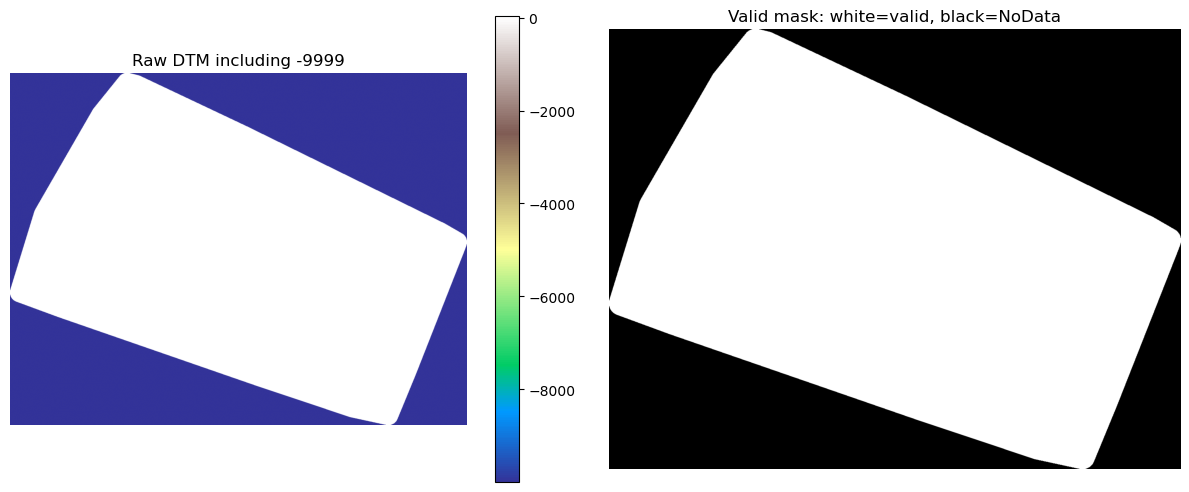

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(dtm_raw, cmap="terrain")
plt.title("Raw DTM including -9999")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(valid, cmap="gray")
plt.title("Valid mask: white=valid, black=NoData")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
dtm = dtm_raw.copy()
dtm[dtm == src.nodata] = np.nan

print(np.nanmin(dtm))
print(np.nanmax(dtm))

8.18
31.6


In [11]:
def read_raster(path):
    """
    Read the first band of a GeoTIFF file and convert NoData values to np.nan.
    """
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, profile

In [12]:
dtm, profile = read_raster(dtm_path)

print("DTM shape:", dtm.shape)
print("DTM min:", np.nanmin(dtm))
print("DTM max:", np.nanmax(dtm))
print("DTM mean:", np.nanmean(dtm))

DTM shape: (1169, 1519)
DTM min: 8.18
DTM max: 31.6
DTM mean: 20.163446


In [13]:
file_paths = {
    "ndvi": os.path.join(data_dir, "ndvi.tif"),
    "ndre": os.path.join(data_dir, "ndre.tif"),
    "gndvi": os.path.join(data_dir, "gndvi.tif"),
    "ndwi": os.path.join(data_dir, "ndwi.tif"),
    "slope": os.path.join(data_dir, "slope.tif"),
    "roughness": os.path.join(data_dir, "roughness.tif"),
    "rel_height": os.path.join(data_dir, "rel_height.tif"),
    "dtm": os.path.join(data_dir, "dtm.tif")
}

rasters = {}
profiles = {}

for name, path in file_paths.items():
    arr, prof = read_raster(path)
    rasters[name] = arr
    profiles[name] = prof

for name, arr in rasters.items():
    print("=" * 40)
    print(name)
    print("shape:", arr.shape)
    print("min:", np.nanmin(arr))
    print("max:", np.nanmax(arr))
    print("mean:", np.nanmean(arr))
    print("nan pixels:", np.isnan(arr).sum())

ndvi
shape: (1170, 1519)
min: -0.49785513
max: 0.6750914
mean: 0.37538308
nan pixels: 725573
ndre
shape: (1170, 1519)
min: -0.4107596
max: 0.17212461
mean: -0.024738895
nan pixels: 725573
gndvi
shape: (1170, 1519)
min: -0.5678799
max: 0.5353484
mean: 0.15029508
nan pixels: 725573
ndwi
shape: (1170, 1519)
min: -0.5353484
max: 0.5678799
mean: -0.15029508
nan pixels: 725573
slope
shape: (1169, 1519)
min: 0.0
max: 88.0078
mean: 17.241594
nan pixels: 729929
roughness
shape: (1169, 1519)
min: 0.0
max: 6.2199993
mean: 0.08019071
nan pixels: 729929
rel_height
shape: (1169, 1518)
min: -1.0636158
max: 12.197256
mean: 0.5491762
nan pixels: 723892
dtm
shape: (1169, 1519)
min: 8.18
max: 31.6
mean: 20.163446
nan pixels: 724557


In [14]:
from rasterio.warp import reproject, Resampling

In [15]:
def align_to_reference(src_path, ref_profile, resampling_method=Resampling.bilinear):
    """
    Align a raster to the reference raster grid.

    Parameters:
        src_path: path to source raster
        ref_profile: profile of reference raster, here dtm.tif
        resampling_method: bilinear for continuous data, nearest for categorical data

    Returns:
        aligned: 2D numpy array aligned to reference grid
    """
    with rasterio.open(src_path) as src:
        src_array = src.read(1).astype("float32")
        src_nodata = src.nodata

        if src_nodata is not None:
            src_array[src_array == src_nodata] = np.nan

        aligned = np.full(
            (ref_profile["height"], ref_profile["width"]),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=src_array,
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=resampling_method
        )

    return aligned

In [16]:
dtm_path = os.path.join(data_dir, "dtm.tif")

with rasterio.open(dtm_path) as ref:
    dtm = ref.read(1).astype("float32")
    ref_profile = ref.profile.copy()
    dtm_nodata = ref.nodata

if dtm_nodata is not None:
    dtm[dtm == dtm_nodata] = np.nan

print("Reference DTM shape:", dtm.shape)
print("Reference CRS:", ref_profile["crs"])
print("Reference transform:", ref_profile["transform"])

Reference DTM shape: (1169, 1519)
Reference CRS: EPSG:32633
Reference transform: | 0.09, 0.00, 324482.84|
| 0.00,-0.09, 6006835.83|
| 0.00, 0.00, 1.00|


In [17]:
aligned_rasters = {}

for name, path in file_paths.items():
    print("Aligning:", name)

    if name == "dtm":
        aligned_rasters[name] = dtm
    else:
        aligned_rasters[name] = align_to_reference(
            path,
            ref_profile,
            resampling_method=Resampling.bilinear
        )

print("Alignment finished.")

Aligning: ndvi
Aligning: ndre
Aligning: gndvi
Aligning: ndwi
Aligning: slope
Aligning: roughness
Aligning: rel_height
Aligning: dtm
Alignment finished.


In [18]:
for name, arr in aligned_rasters.items():
    print(name, arr.shape, "nan:", np.isnan(arr).sum(), 
          "min:", np.nanmin(arr), 
          "max:", np.nanmax(arr))

ndvi (1169, 1519) nan: 725522 min: -0.47990656 max: 0.6698294
ndre (1169, 1519) nan: 725522 min: -0.35319573 max: 0.1716958
gndvi (1169, 1519) nan: 725522 min: -0.5645691 max: 0.4190333
ndwi (1169, 1519) nan: 725522 min: -0.4190333 max: 0.5645691
slope (1169, 1519) nan: 729929 min: 0.0 max: 88.0073
roughness (1169, 1519) nan: 729929 min: 0.0 max: 6.2199793
rel_height (1169, 1519) nan: 725061 min: -0.9491563 max: 12.188643
dtm (1169, 1519) nan: 724557 min: 8.18 max: 31.6


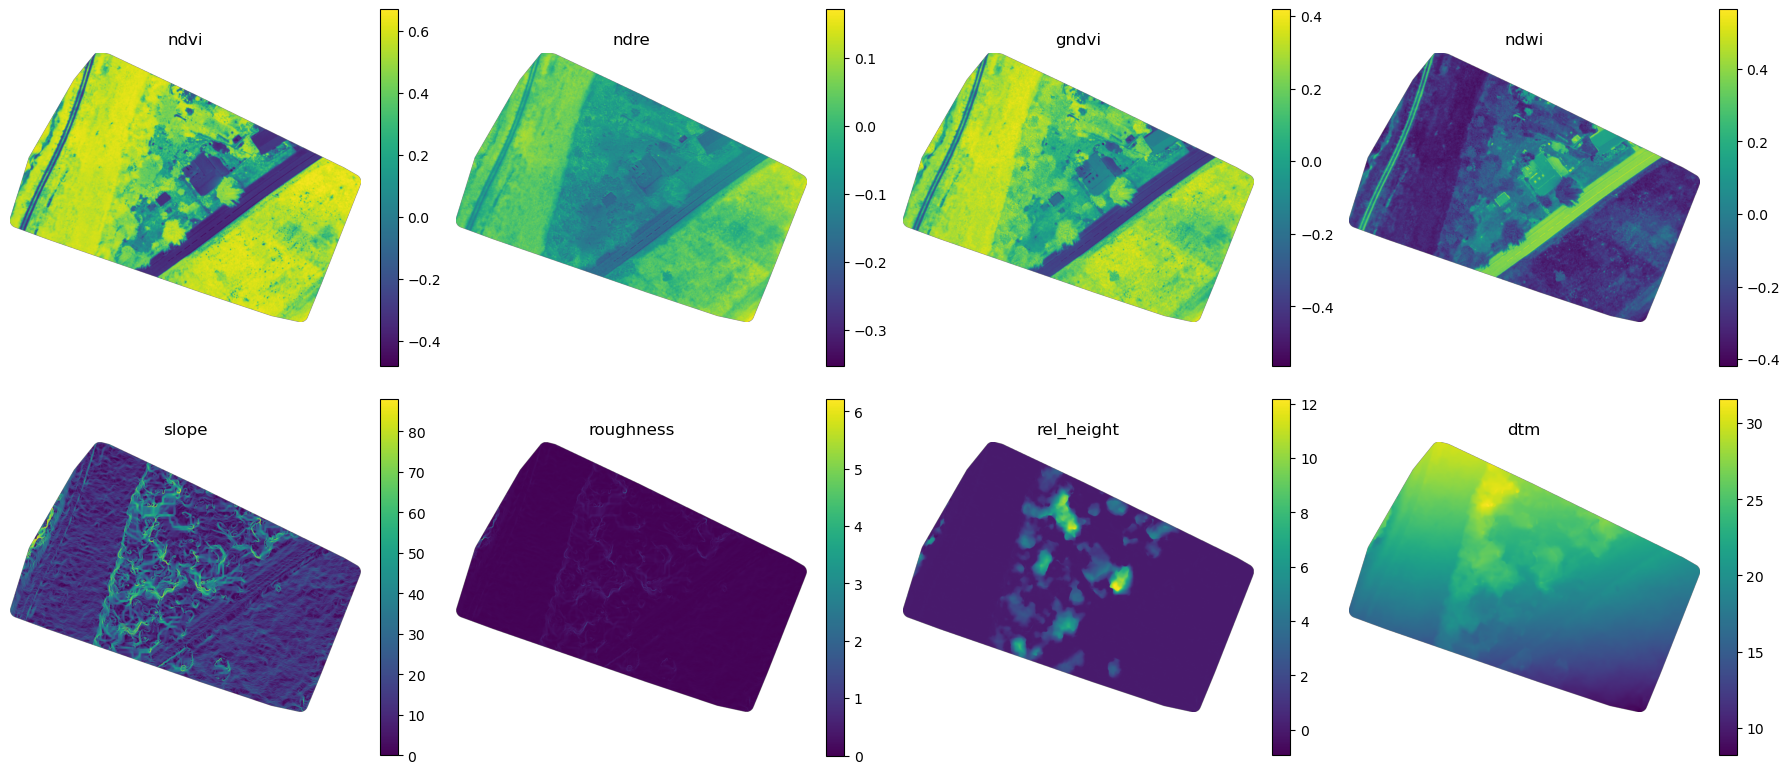

In [19]:
feature_order = [
    "ndvi", "ndre", "gndvi", "ndwi",
    "slope", "roughness", "rel_height", "dtm"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, name in zip(axes.ravel(), feature_order):
    im = ax.imshow(aligned_rasters[name], cmap="viridis")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

In [20]:
aligned_dir = "../data_aligned"
os.makedirs(aligned_dir, exist_ok=True)

In [21]:
aligned_profile = ref_profile.copy()
aligned_profile.update(
    dtype=rasterio.float32,
    count=1,
    nodata=np.nan
)

for name, arr in aligned_rasters.items():
    out_path = os.path.join(aligned_dir, f"{name}_aligned.tif")
    with rasterio.open(out_path, "w", **aligned_profile) as dst:
        dst.write(arr.astype("float32"), 1)
    print("Saved:", out_path)

Saved: ../data_aligned\ndvi_aligned.tif
Saved: ../data_aligned\ndre_aligned.tif
Saved: ../data_aligned\gndvi_aligned.tif
Saved: ../data_aligned\ndwi_aligned.tif
Saved: ../data_aligned\slope_aligned.tif
Saved: ../data_aligned\roughness_aligned.tif
Saved: ../data_aligned\rel_height_aligned.tif
Saved: ../data_aligned\dtm_aligned.tif


In [22]:
feature_order = [
    "ndvi",
    "ndre",
    "gndvi",
    "ndwi",
    "slope",
    "roughness",
    "rel_height",
    "dtm"
]

valid_mask = np.ones_like(aligned_rasters["dtm"], dtype=bool)

for name in feature_order:
    valid_mask &= np.isfinite(aligned_rasters[name])

print("Total pixels:", valid_mask.size)
print("Valid pixels:", valid_mask.sum())
print("Invalid pixels:", valid_mask.size - valid_mask.sum())
print("Valid ratio:", valid_mask.sum() / valid_mask.size)

Total pixels: 1775711
Valid pixels: 1045782
Invalid pixels: 729929
Valid ratio: 0.5889370511305049


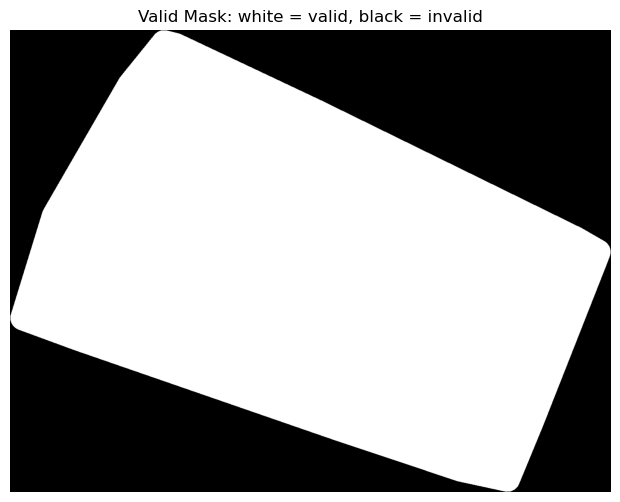

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(valid_mask, cmap="gray")
plt.title("Valid Mask: white = valid, black = invalid")
plt.axis("off")
plt.show()

In [24]:
X = np.column_stack([
    aligned_rasters[name][valid_mask] for name in feature_order
])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (1045782, 8)


In [25]:
for i, name in enumerate(feature_order):
    print("=" * 40)
    print(name)
    print("min:", np.min(X[:, i]))
    print("max:", np.max(X[:, i]))
    print("mean:", np.mean(X[:, i]))

ndvi
min: -0.47990656
max: 0.6698294
mean: 0.37531206
ndre
min: -0.35319573
max: 0.17113034
mean: -0.024914498
gndvi
min: -0.5319382
max: 0.41672778
mean: 0.15024501
ndwi
min: -0.41672778
max: 0.5319382
mean: -0.15024501
slope
min: 0.0
max: 88.0073
mean: 17.241585
roughness
min: 0.0
max: 6.2199793
mean: 0.08019066
rel_height
min: -0.9491563
max: 12.188643
mean: 0.5502427
dtm
min: 8.194997
max: 31.6
mean: 20.166891


In [26]:
X_clipped = X.copy()

for i, name in enumerate(feature_order):
    low = np.percentile(X[:, i], 1)
    high = np.percentile(X[:, i], 99)

    X_clipped[:, i] = np.clip(X[:, i], low, high)

    print(f"{name}: clipped to [{low:.4f}, {high:.4f}]")

ndvi: clipped to [-0.3564, 0.6336]
ndre: clipped to [-0.1851, 0.1108]
gndvi: clipped to [-0.3995, 0.3686]
ndwi: clipped to [-0.3686, 0.3995]
slope: clipped to [1.1564, 61.6454]
roughness: clipped to [0.0060, 0.4300]
rel_height: clipped to [-0.0144, 7.9354]
dtm: clipped to [9.8600, 30.0052]


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clipped)

print("Scaled feature matrix shape:", X_scaled.shape)

for i, name in enumerate(feature_order):
    print("=" * 40)
    print(name)
    print("min:", X_scaled[:, i].min())
    print("max:", X_scaled[:, i].max())
    print("mean:", X_scaled[:, i].mean())

Scaled feature matrix shape: (1045782, 8)
ndvi
min: 0.0
max: 1.0
mean: 0.73930526
ndre
min: 0.0
max: 0.9999999
mean: 0.5416265
gndvi
min: 0.0
max: 0.99999994
mean: 0.71594644
ndwi
min: 0.0
max: 1.0
mean: 0.28405347
slope
min: 0.0
max: 0.99999994
mean: 0.2648025
roughness
min: 0.0
max: 1.0
mean: 0.1685795
rel_height
min: 0.0
max: 1.0
mean: 0.06926155
dtm
min: 0.0
max: 1.0
mean: 0.5116927


In [28]:
os.makedirs("../outputs/intermediate", exist_ok=True)

np.save("../outputs/intermediate/X_scaled.npy", X_scaled)
np.save("../outputs/intermediate/valid_mask.npy", valid_mask)

print("Saved X_scaled and valid_mask.")

Saved X_scaled and valid_mask.


In [29]:
import numpy as np

np.random.seed(42)

n_samples = min(30000, X_scaled.shape[0])
sample_idx = np.random.choice(X_scaled.shape[0], size=n_samples, replace=False)

X_sample = X_scaled[sample_idx]

print("Original X shape:", X_scaled.shape)
print("Sample X shape:", X_sample.shape)

Original X shape: (1045782, 8)
Sample X shape: (30000, 8)


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_results = []

for k in [2, 3, 4, 5, 6]:
    print("=" * 50)
    print("Running KMeans with K =", k)
    
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_sample = km.fit_predict(X_sample)
    
    sil = silhouette_score(X_sample, labels_sample)
    dbi = davies_bouldin_score(X_sample, labels_sample)
    
    k_results.append((k, sil, dbi))
    
    print(f"K={k}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies-Bouldin Index: {dbi:.4f}")

Running KMeans with K = 2
K=2
Silhouette Score: 0.4532
Davies-Bouldin Index: 0.9194
Running KMeans with K = 3
K=3
Silhouette Score: 0.3577
Davies-Bouldin Index: 1.2289
Running KMeans with K = 4
K=4
Silhouette Score: 0.3586
Davies-Bouldin Index: 1.2309
Running KMeans with K = 5
K=5
Silhouette Score: 0.3203
Davies-Bouldin Index: 1.1381
Running KMeans with K = 6
K=6
Silhouette Score: 0.3381
Davies-Bouldin Index: 1.0462


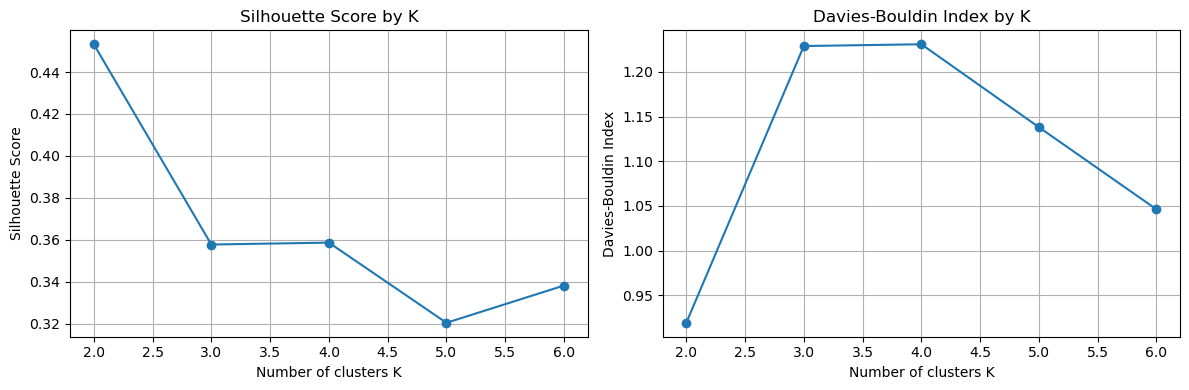

In [31]:
import matplotlib.pyplot as plt

ks = [r[0] for r in k_results]
sils = [r[1] for r in k_results]
dbis = [r[2] for r in k_results]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ks, sils, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ks, dbis, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index by K")
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
from sklearn.mixture import GaussianMixture

best_k = 3

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=42,
    n_init=3,
    max_iter=300
)

print("Training GMM...")
gmm.fit(X_sample)
print("GMM training finished.")

Training GMM...
GMM training finished.


In [33]:
print("Predicting full map...")
gmm_labels = gmm.predict(X_scaled)
print("Prediction finished.")

print("Labels shape:", gmm_labels.shape)
print("Unique labels:", np.unique(gmm_labels))

Predicting full map...
Prediction finished.
Labels shape: (1045782,)
Unique labels: [0 1 2]


In [34]:
gmm_map = np.full(valid_mask.shape, -1, dtype=np.int32)
gmm_map[valid_mask] = gmm_labels

print("GMM map shape:", gmm_map.shape)
print("Unique values:", np.unique(gmm_map))

GMM map shape: (1169, 1519)
Unique values: [-1  0  1  2]


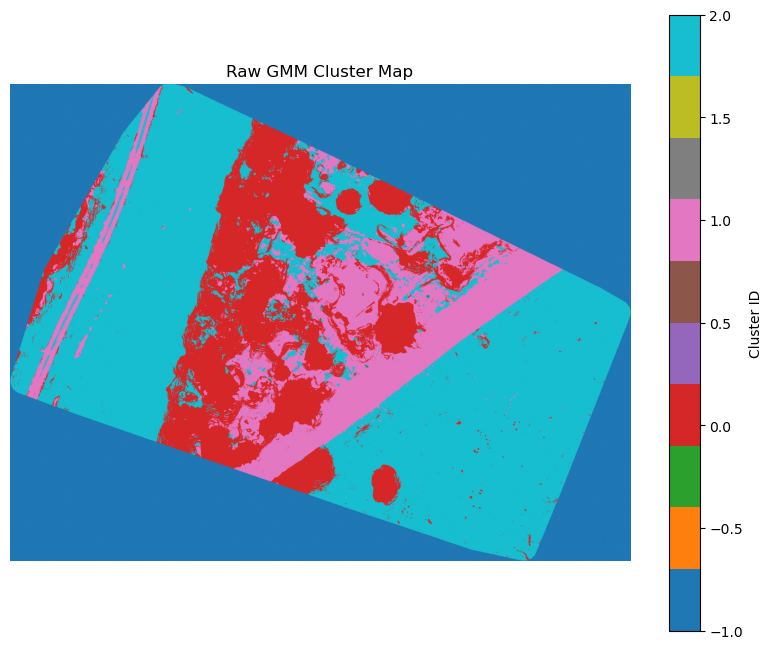

In [35]:
plt.figure(figsize=(10, 8))
plt.imshow(gmm_map, cmap="tab10")
plt.title("Raw GMM Cluster Map")
plt.colorbar(label="Cluster ID")
plt.axis("off")
plt.show()

In [36]:
feature_order = [
    "ndvi",
    "ndre",
    "gndvi",
    "ndwi",
    "slope",
    "roughness",
    "rel_height",
    "dtm"
]

for c in range(best_k):
    idx = gmm_labels == c
    print("=" * 60)
    print(f"Cluster {c}")
    print("Number of pixels:", idx.sum())
    
    for i, fname in enumerate(feature_order):
        raw_mean = X[idx, i].mean()
        scaled_mean = X_scaled[idx, i].mean()
        print(f"{fname:12s} raw_mean={raw_mean:10.4f} | scaled_mean={scaled_mean:8.4f}")

Cluster 0
Number of pixels: 260604
ndvi         raw_mean=    0.4030 | scaled_mean=  0.7671
ndre         raw_mean=   -0.0745 | scaled_mean=  0.3738
gndvi        raw_mean=    0.1559 | scaled_mean=  0.7231
ndwi         raw_mean=   -0.1559 | scaled_mean=  0.2769
slope        raw_mean=   27.9842 | scaled_mean=  0.4387
roughness    raw_mean=    0.1533 | scaled_mean=  0.3217
rel_height   raw_mean=    1.9307 | scaled_mean=  0.2376
dtm          raw_mean=   22.2289 | scaled_mean=  0.6133
Cluster 1
Number of pixels: 193712
ndvi         raw_mean=   -0.1358 | scaled_mean=  0.2242
ndre         raw_mean=   -0.1215 | scaled_mean=  0.2184
gndvi        raw_mean=   -0.1840 | scaled_mean=  0.2823
ndwi         raw_mean=    0.1840 | scaled_mean=  0.7177
slope        raw_mean=   15.1118 | scaled_mean=  0.2309
roughness    raw_mean=    0.0638 | scaled_mean=  0.1365
rel_height   raw_mean=    0.3504 | scaled_mean=  0.0459
dtm          raw_mean=   20.8189 | scaled_mean=  0.5440
Cluster 2
Number of pixels: 591466

In [37]:
cluster_risk = {}

for c in range(best_k):
    idx = gmm_labels == c
    mean_scaled = X_scaled[idx].mean(axis=0)

    # 特征顺序：
    # 0 ndvi
    # 1 ndre
    # 2 gndvi
    # 3 ndwi
    # 4 slope
    # 5 roughness
    # 6 rel_height
    # 7 dtm

    vegetation_risk = np.mean([
        mean_scaled[0],
        mean_scaled[1],
        mean_scaled[2]
    ])

    water_risk = mean_scaled[3]

    terrain_risk = np.mean([
        mean_scaled[4],
        mean_scaled[5],
        mean_scaled[6]
    ])

    # 这里地形权重最高，植被其次，水分补充
    risk = 0.45 * terrain_risk + 0.35 * vegetation_risk + 0.20 * water_risk

    cluster_risk[c] = risk

    print("=" * 50)
    print(f"Cluster {c}")
    print(f"vegetation_risk = {vegetation_risk:.4f}")
    print(f"water_risk      = {water_risk:.4f}")
    print(f"terrain_risk    = {terrain_risk:.4f}")
    print(f"total risk      = {risk:.4f}")

Cluster 0
vegetation_risk = 0.6213
water_risk      = 0.2769
terrain_risk    = 0.3326
total risk      = 0.4225
Cluster 1
vegetation_risk = 0.2417
water_risk      = 0.7177
terrain_risk    = 0.1377
total risk      = 0.2901
Cluster 2
vegetation_risk = 0.8240
water_risk      = 0.1452
terrain_risk    = 0.1046
total risk      = 0.3645


In [38]:
sorted_clusters = sorted(cluster_risk, key=cluster_risk.get)

print("Clusters from low risk to high risk:", sorted_clusters)

# 最低风险 → 0 easy
# 中等风险 → 1 medium
# 最高风险 → 2 hard
mapping = {old_cluster: new_label for new_label, old_cluster in enumerate(sorted_clusters)}

print("Mapping:", mapping)

Clusters from low risk to high risk: [1, 2, 0]
Mapping: {1: 0, 2: 1, 0: 2}


In [39]:
semantic_map = np.full_like(gmm_map, -1)

for old_cluster, new_label in mapping.items():
    semantic_map[gmm_map == old_cluster] = new_label

print("Semantic map unique values:", np.unique(semantic_map))

Semantic map unique values: [-1  0  1  2]


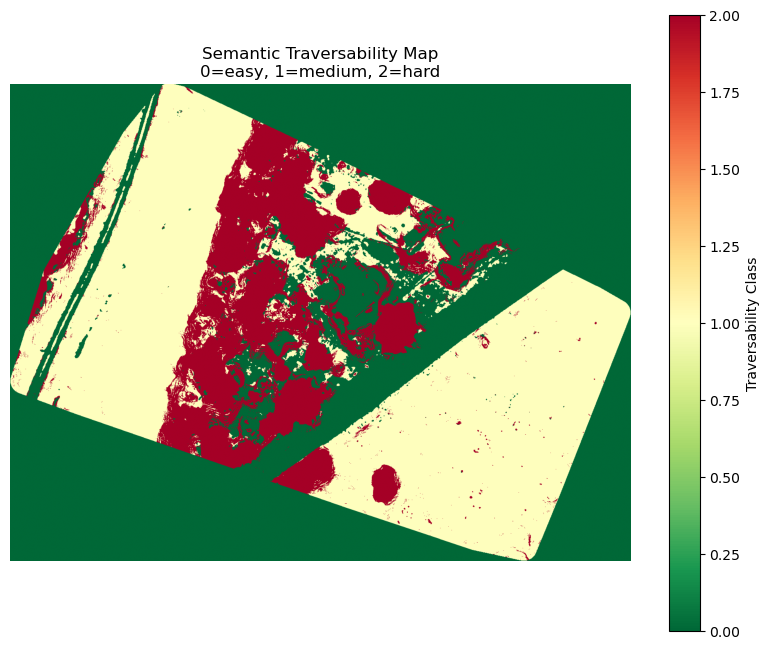

In [40]:
plt.figure(figsize=(10, 8))
plt.imshow(semantic_map, cmap="RdYlGn_r", vmin=0, vmax=2)
plt.title("Semantic Traversability Map\n0=easy, 1=medium, 2=hard")
plt.colorbar(label="Traversability Class")
plt.axis("off")
plt.show()

In [41]:
print("Unique values in semantic_map:", np.unique(semantic_map))

Unique values in semantic_map: [-1  0  1  2]


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 把 -1 区域视为无效区域
semantic_map_masked = np.ma.masked_where(semantic_map == -1, semantic_map)

print("Masked map created.")
print("Shape:", semantic_map_masked.shape)

Masked map created.
Shape: (1169, 1519)


In [43]:
cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color="white")

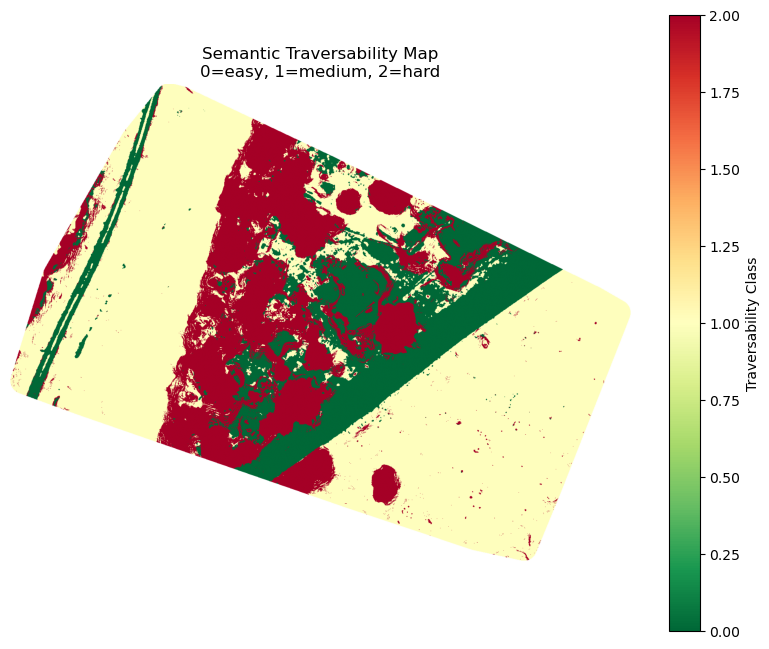

In [44]:
plt.figure(figsize=(10, 8))
img = plt.imshow(semantic_map_masked, cmap=cmap, vmin=0, vmax=2)

plt.title("Semantic Traversability Map\n0=easy, 1=medium, 2=hard")
cbar = plt.colorbar(img, label="Traversability Class")
plt.axis("off")
plt.show()

In [45]:
invalid_mask = semantic_map == -1

print("Invalid pixels:", invalid_mask.sum())
print("Valid pixels:", (~invalid_mask).sum())

Invalid pixels: 729929
Valid pixels: 1045782


In [46]:
from scipy.ndimage import median_filter
import numpy as np
import matplotlib.pyplot as plt

# 1. 保存无效区域
invalid_mask = semantic_map == -1

# 2. 为了滤波，临时把无效区域设成 hard
semantic_for_filter = semantic_map.copy()
semantic_for_filter[invalid_mask] = 2

# 3. 中值滤波
semantic_smooth = median_filter(semantic_for_filter, size=5)

# 4. 恢复无效区域
semantic_smooth[invalid_mask] = -1

print("Unique values before smoothing:", np.unique(semantic_map))
print("Unique values after smoothing:", np.unique(semantic_smooth))

Unique values before smoothing: [-1  0  1  2]
Unique values after smoothing: [-1  0  1  2]


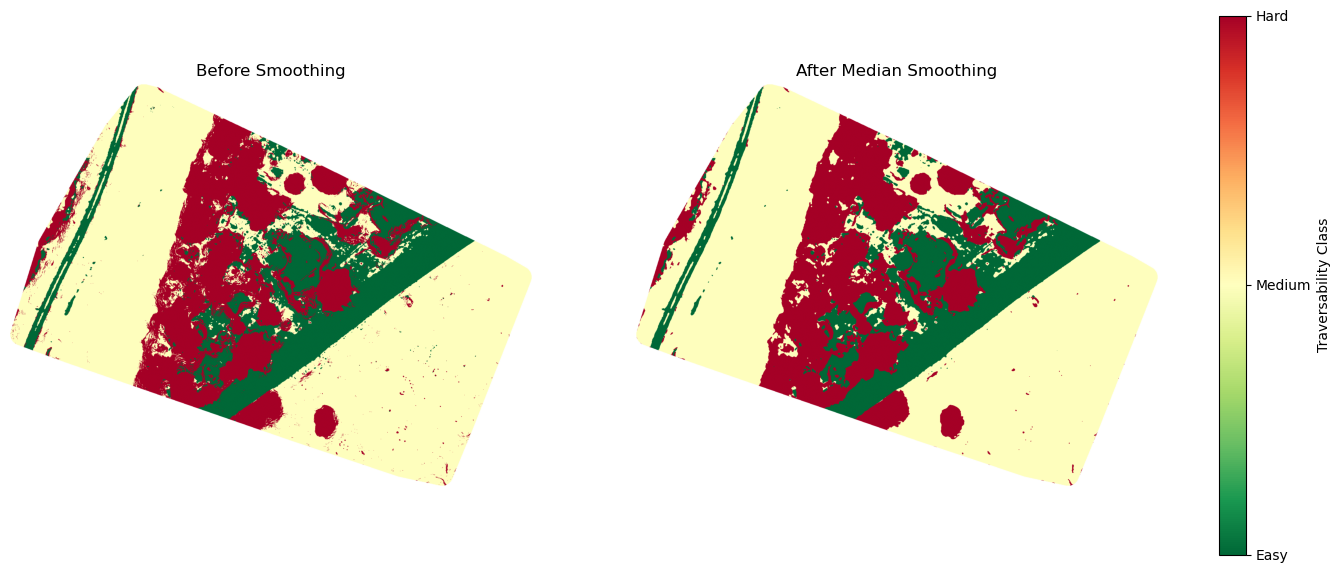

In [47]:
# masked display
semantic_map_masked = np.ma.masked_where(semantic_map == -1, semantic_map)
semantic_smooth_masked = np.ma.masked_where(semantic_smooth == -1, semantic_smooth)

cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color="white")

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
img1 = plt.imshow(semantic_map_masked, cmap=cmap, vmin=0, vmax=2)
plt.title("Before Smoothing")
plt.axis("off")

plt.subplot(1, 2, 2)
img2 = plt.imshow(semantic_smooth_masked, cmap=cmap, vmin=0, vmax=2)
plt.title("After Median Smoothing")
plt.axis("off")

cbar = plt.colorbar(img2, ax=plt.gcf().axes, ticks=[0, 1, 2], fraction=0.025)
cbar.set_label("Traversability Class")
cbar.ax.set_yticklabels(["Easy", "Medium", "Hard"])

plt.show()

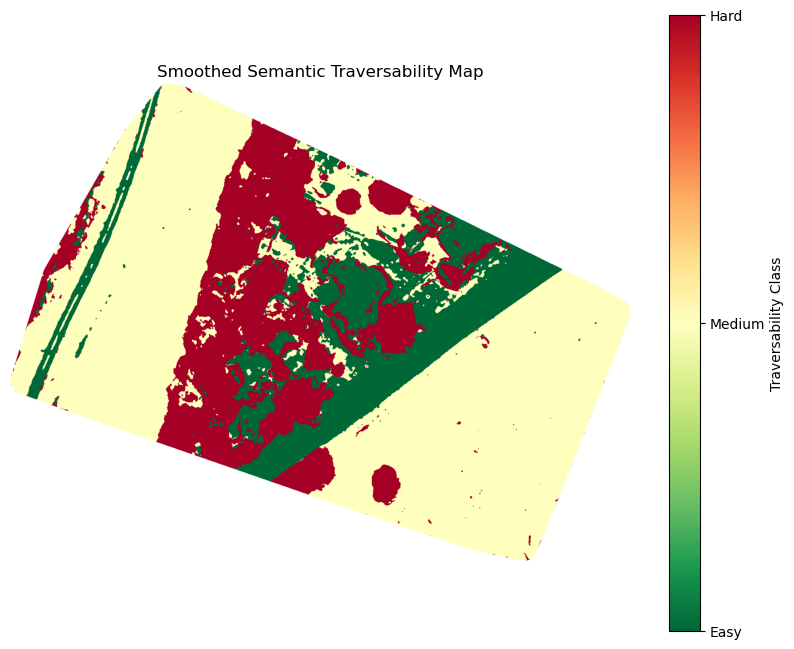

In [48]:
plt.figure(figsize=(10, 8))

semantic_smooth_masked = np.ma.masked_where(semantic_smooth == -1, semantic_smooth)

cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color="white")

img = plt.imshow(semantic_smooth_masked, cmap=cmap, vmin=0, vmax=2)

cbar = plt.colorbar(img, ticks=[0, 1, 2])
cbar.set_label("Traversability Class")
cbar.ax.set_yticklabels(["Easy", "Medium", "Hard"])

plt.title("Smoothed Semantic Traversability Map")
plt.axis("off")

plt.savefig("../outputs/figures/semantic_traversability_smoothed.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
import os

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/maps", exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


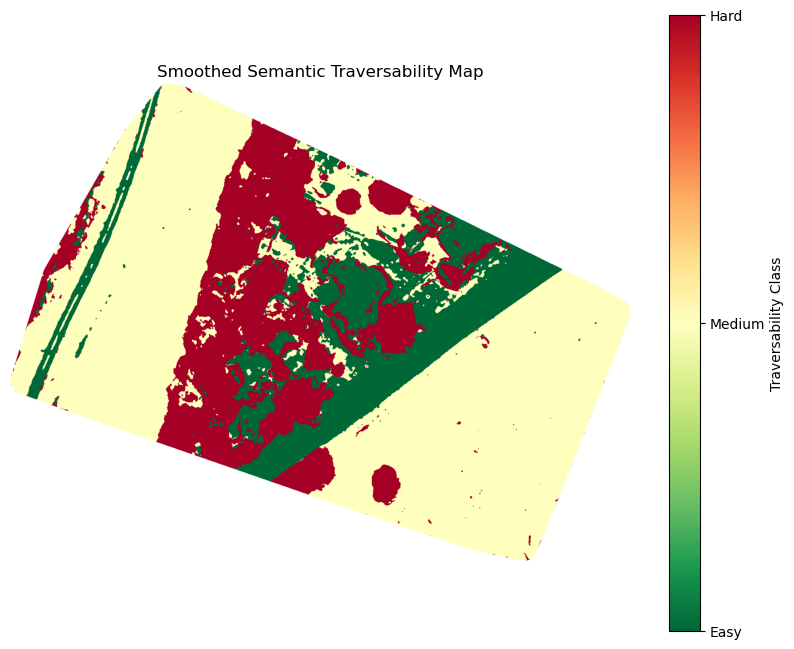

In [50]:
plt.figure(figsize=(10, 8))

semantic_smooth_masked = np.ma.masked_where(semantic_smooth == -1, semantic_smooth)

cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color="white")

img = plt.imshow(semantic_smooth_masked, cmap=cmap, vmin=0, vmax=2)

cbar = plt.colorbar(img, ticks=[0, 1, 2])
cbar.set_label("Traversability Class")
cbar.ax.set_yticklabels(["Easy", "Medium", "Hard"])

plt.title("Smoothed Semantic Traversability Map")
plt.axis("off")

plt.savefig("../outputs/figures/semantic_traversability_smoothed.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
rel = aligned_rasters["rel_height"]

print("rel_height min:", np.nanmin(rel))
print("rel_height max:", np.nanmax(rel))
print("rel_height mean:", np.nanmean(rel))

for p in [50, 75, 90, 95, 97, 99]:
    print(f"Percentile {p}:", np.nanpercentile(rel, p))

rel_height min: -0.9491563
rel_height max: 12.188643
rel_height mean: 0.5493356
Percentile 50: 0.009998538
Percentile 75: 0.05549209
Percentile 90: 1.9011798
Percentile 95: 3.5242062
Percentile 97: 4.9232106
Percentile 99: 7.9256115


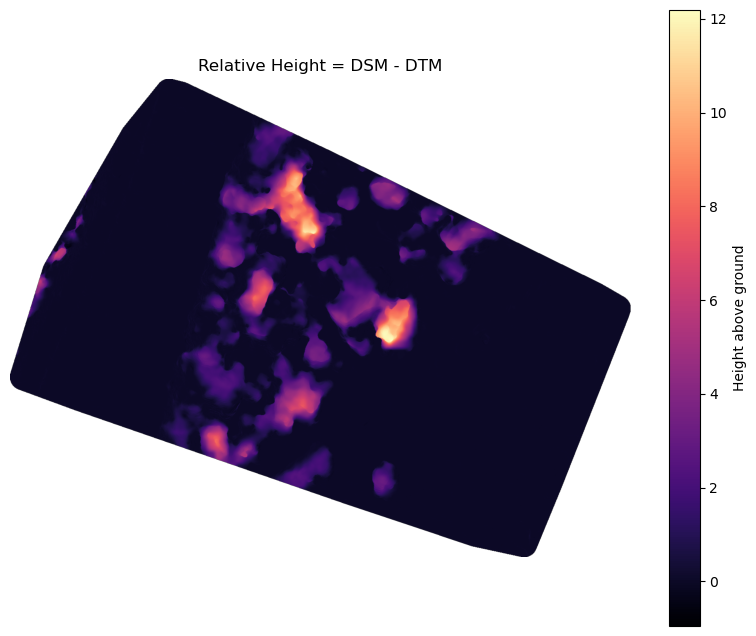

In [52]:
plt.figure(figsize=(10, 8))

rel_masked = np.ma.masked_invalid(rel)

img = plt.imshow(rel_masked, cmap="magma")
plt.title("Relative Height = DSM - DTM")
plt.colorbar(label="Height above ground")
plt.axis("off")
plt.show()

In [53]:
height_threshold = 1.0

In [54]:
height_threshold = 1.0

obstacle_mask = aligned_rasters["rel_height"] > height_threshold

# 无效区域也不应通行
invalid_mask = semantic_map == -1

print("Obstacle pixels:", obstacle_mask.sum())
print("Invalid pixels:", invalid_mask.sum())

Obstacle pixels: 160972
Invalid pixels: 729929


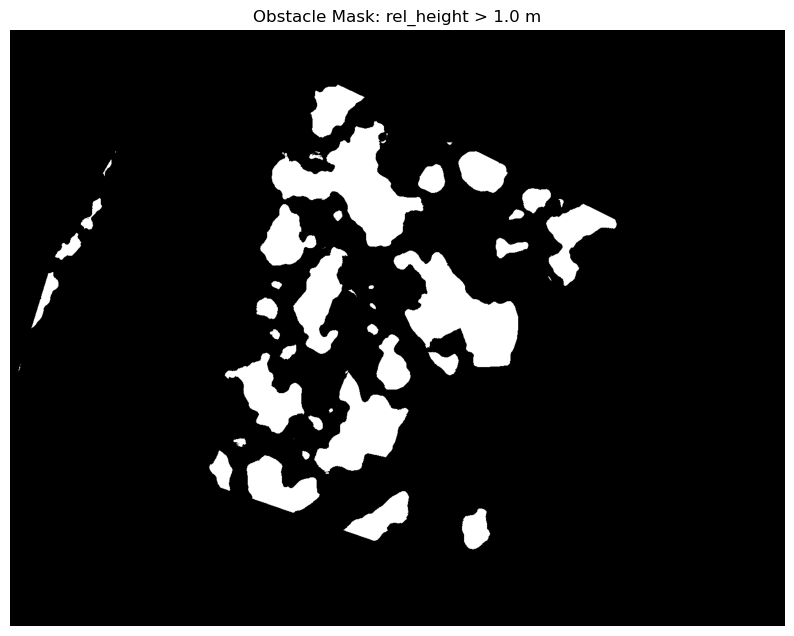

In [55]:
plt.figure(figsize=(10, 8))
plt.imshow(obstacle_mask, cmap="gray")
plt.title(f"Obstacle Mask: rel_height > {height_threshold} m")
plt.axis("off")
plt.show()

In [56]:
semantic_corrected = semantic_smooth.copy()

# 高障碍物强制设为 blocked
semantic_corrected[obstacle_mask] = 3

# 原始无效区域仍然保持 invalid
semantic_corrected[invalid_mask] = -1

print("Unique values:", np.unique(semantic_corrected))

Unique values: [-1  0  1  2  3]


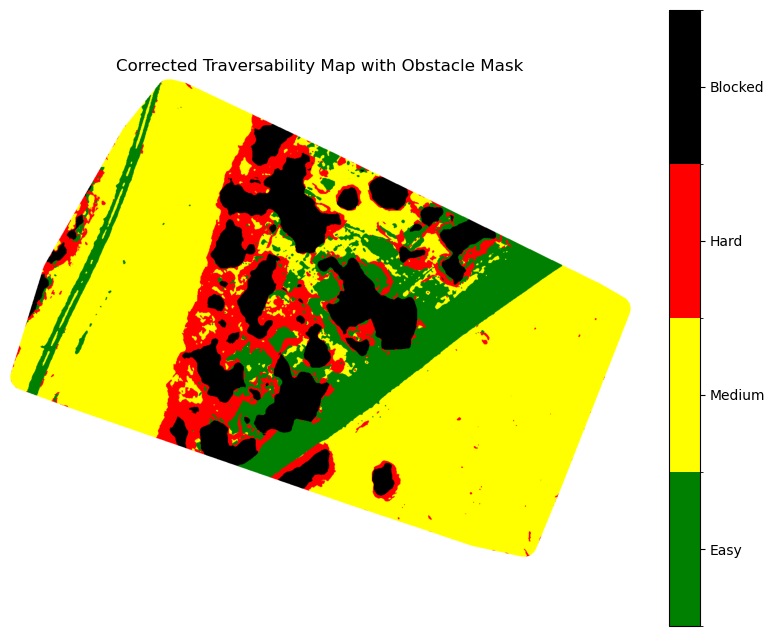

In [57]:
import matplotlib.colors as mcolors

# masked invalid
semantic_corrected_masked = np.ma.masked_where(
    semantic_corrected == -1,
    semantic_corrected
)

# 自定义颜色：easy, medium, hard, blocked
colors = [
    "green",      # 0 easy
    "yellow",     # 1 medium
    "red",        # 2 hard
    "black"       # 3 blocked
]

cmap_custom = mcolors.ListedColormap(colors)
cmap_custom.set_bad(color="white")

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap_custom.N)

plt.figure(figsize=(10, 8))
img = plt.imshow(
    semantic_corrected_masked,
    cmap=cmap_custom,
    norm=norm
)

cbar = plt.colorbar(img, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["Easy", "Medium", "Hard", "Blocked"])

plt.title("Corrected Traversability Map with Obstacle Mask")
plt.axis("off")
plt.show()

In [58]:
costmap_corrected = np.full(semantic_corrected.shape, 255, dtype=np.uint8)

costmap_corrected[semantic_corrected == 0] = 30
costmap_corrected[semantic_corrected == 1] = 120
costmap_corrected[semantic_corrected == 2] = 220
costmap_corrected[semantic_corrected == 3] = 255
costmap_corrected[semantic_corrected == -1] = 255

print("Costmap unique values:", np.unique(costmap_corrected))

Costmap unique values: [ 30 120 220 255]


In [59]:
costmap = costmap_corrected

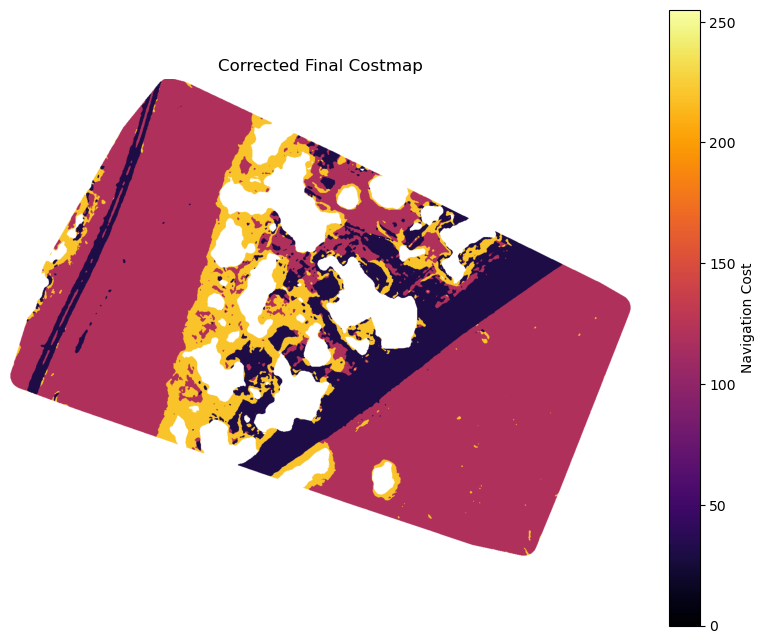

In [60]:
costmap_masked = np.ma.masked_where(costmap_corrected == 255, costmap_corrected)

cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.figure(figsize=(10, 8))
img = plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)
plt.colorbar(img, label="Navigation Cost")
plt.title("Corrected Final Costmap")
plt.axis("off")
plt.show()

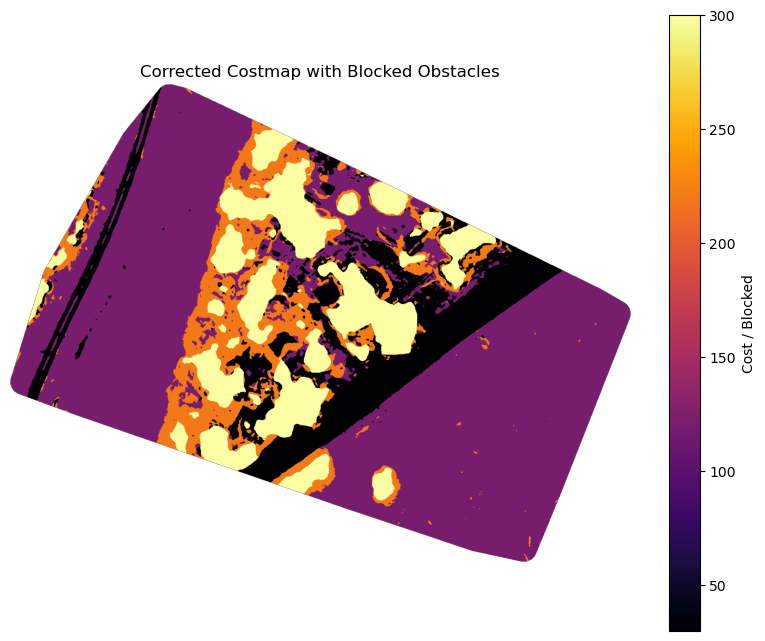

In [61]:
display_map = costmap_corrected.astype(float)

# invalid 和 blocked 都是 255，但为了显示区分：
# obstacle 显示为 300，invalid mask 掉
display_map[semantic_corrected == 3] = 300
display_map[semantic_corrected == -1] = np.nan

plt.figure(figsize=(10, 8))
img = plt.imshow(display_map, cmap="inferno")
plt.colorbar(img, label="Cost / Blocked")
plt.title("Corrected Costmap with Blocked Obstacles")
plt.axis("off")
plt.show()

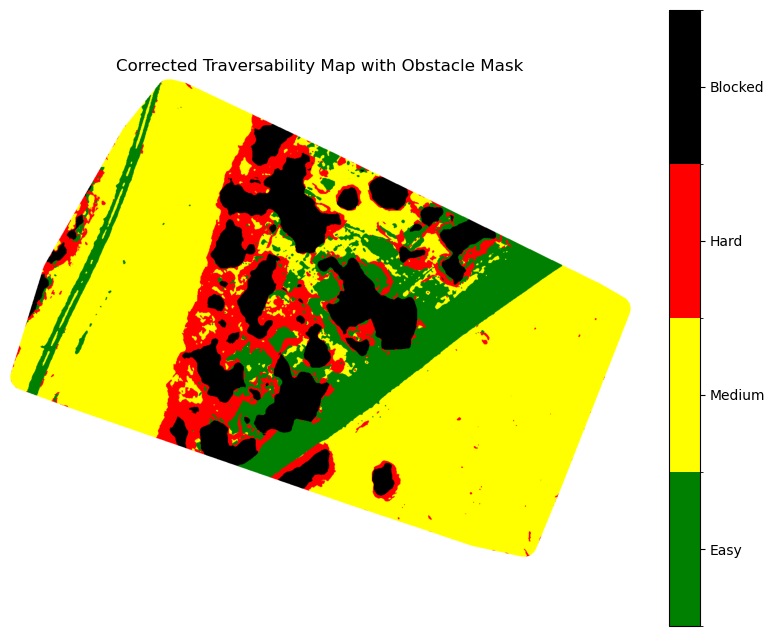

Saved corrected costmap.


In [62]:
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/maps", exist_ok=True)

# 保存 semantic corrected 图像
plt.figure(figsize=(10, 8))
img = plt.imshow(
    semantic_corrected_masked,
    cmap=cmap_custom,
    norm=norm
)
cbar = plt.colorbar(img, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["Easy", "Medium", "Hard", "Blocked"])
plt.title("Corrected Traversability Map with Obstacle Mask")
plt.axis("off")
plt.savefig("../outputs/figures/semantic_traversability_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

# 保存 corrected costmap tif
costmap_profile = ref_profile.copy()
costmap_profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=255
)

with rasterio.open("../outputs/maps/costmap_corrected.tif", "w", **costmap_profile) as dst:
    dst.write(costmap_corrected, 1)

print("Saved corrected costmap.")

In [65]:
import os
import numpy as np

os.makedirs("../outputs/intermediate", exist_ok=True)

np.save("../outputs/intermediate/semantic_map.npy", semantic_map)
np.save("../outputs/intermediate/semantic_smooth.npy", semantic_smooth)
np.save("../outputs/intermediate/costmap.npy", costmap)
np.save("../outputs/intermediate/valid_mask.npy", valid_mask)

print("Saved intermediate variables.")

Saved intermediate variables.


In [66]:
if "semantic_corrected" in globals():
    np.save("../outputs/intermediate/semantic_corrected.npy", semantic_corrected)

if "costmap_corrected" in globals():
    np.save("../outputs/intermediate/costmap_corrected.npy", costmap_corrected)

print("Saved corrected variables if available.")

Saved corrected variables if available.


In [67]:
if "costmap_corrected" in globals():
    with rasterio.open("../outputs/maps/costmap_corrected.tif", "w", **costmap_profile) as dst:
        dst.write(costmap_corrected.astype("uint8"), 1)

    print("Saved: ../outputs/maps/costmap_corrected.tif")

Saved: ../outputs/maps/costmap_corrected.tif


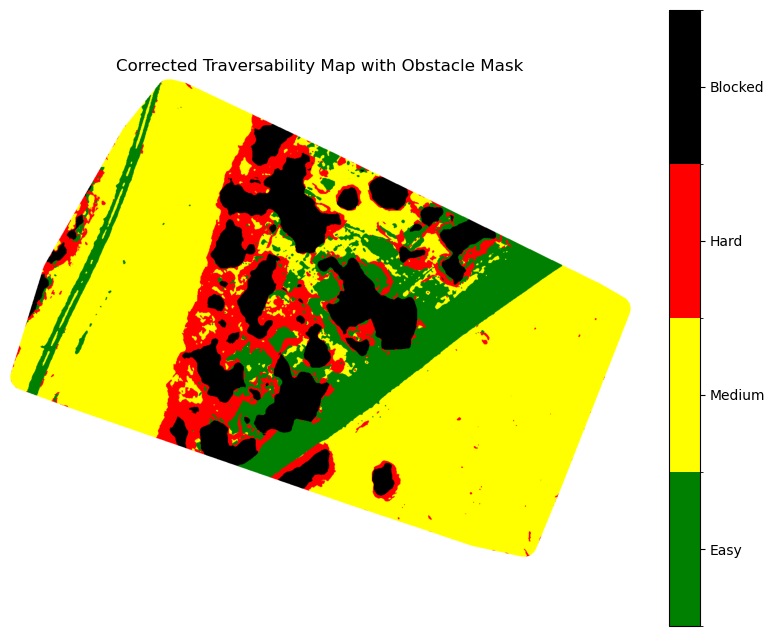

Saved: ../outputs/figures/semantic_traversability_corrected.png


In [68]:
if "semantic_corrected" in globals():
    import matplotlib.colors as mcolors

    semantic_corrected_masked = np.ma.masked_where(
        semantic_corrected == -1,
        semantic_corrected
    )

    colors = ["green", "yellow", "red", "black"]
    cmap_custom = mcolors.ListedColormap(colors)
    cmap_custom.set_bad(color="white")

    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap_custom.N)

    plt.figure(figsize=(10, 8))
    img = plt.imshow(
        semantic_corrected_masked,
        cmap=cmap_custom,
        norm=norm
    )

    cbar = plt.colorbar(img, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(["Easy", "Medium", "Hard", "Blocked"])

    plt.title("Corrected Traversability Map with Obstacle Mask")
    plt.axis("off")
    plt.savefig("../outputs/figures/semantic_traversability_corrected.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: ../outputs/figures/semantic_traversability_corrected.png")

In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import matplotlib.colors as mcolors
from scipy.ndimage import median_filter

In [70]:
print(os.getcwd())

C:\Users\ROG\Desktop\uav_navigation_project\notebook


In [71]:
print("Intermediate files:")
print(os.listdir("../outputs/intermediate"))

print("\nMap files:")
print(os.listdir("../outputs/maps"))

print("\nFigure files:")
print(os.listdir("../outputs/figures"))

Intermediate files:
['costmap.npy', 'costmap_corrected.npy', 'semantic_corrected.npy', 'semantic_map.npy', 'semantic_smooth.npy', 'valid_mask.npy', 'X_scaled.npy']

Map files:
['costmap_corrected.tif', 'costmap_current.tif']

Figure files:
['semantic_traversability_corrected.png', 'semantic_traversability_smoothed.png']


In [72]:
semantic_map = np.load("../outputs/intermediate/semantic_map.npy")
semantic_smooth = np.load("../outputs/intermediate/semantic_smooth.npy")
costmap = np.load("../outputs/intermediate/costmap.npy")
valid_mask = np.load("../outputs/intermediate/valid_mask.npy")

print("Loaded saved variables.")
print("semantic_map shape:", semantic_map.shape)
print("semantic_smooth shape:", semantic_smooth.shape)
print("costmap shape:", costmap.shape)
print("valid_mask shape:", valid_mask.shape)

print("semantic_map unique:", np.unique(semantic_map))
print("semantic_smooth unique:", np.unique(semantic_smooth))
print("costmap unique:", np.unique(costmap))

Loaded saved variables.
semantic_map shape: (1169, 1519)
semantic_smooth shape: (1169, 1519)
costmap shape: (1169, 1519)
valid_mask shape: (1169, 1519)
semantic_map unique: [-1  0  1  2]
semantic_smooth unique: [-1  0  1  2]
costmap unique: [ 30 120 220 255]


In [73]:
if os.path.exists("../outputs/intermediate/semantic_corrected.npy"):
    semantic_corrected = np.load("../outputs/intermediate/semantic_corrected.npy")
    print("Loaded semantic_corrected.")
    print("semantic_corrected unique:", np.unique(semantic_corrected))

if os.path.exists("../outputs/intermediate/costmap_corrected.npy"):
    costmap_corrected = np.load("../outputs/intermediate/costmap_corrected.npy")
    print("Loaded costmap_corrected.")
    print("costmap_corrected unique:", np.unique(costmap_corrected))

Loaded semantic_corrected.
semantic_corrected unique: [-1  0  1  2  3]
Loaded costmap_corrected.
costmap_corrected unique: [ 30 120 220 255]


In [74]:
import numpy as np
import matplotlib.pyplot as plt
import os

costmap = costmap_corrected.copy()

print("Planning costmap ready.")
print("costmap shape:", costmap.shape)
print("costmap unique values:", np.unique(costmap))

Planning costmap ready.
costmap shape: (1169, 1519)
costmap unique values: [ 30 120 220 255]


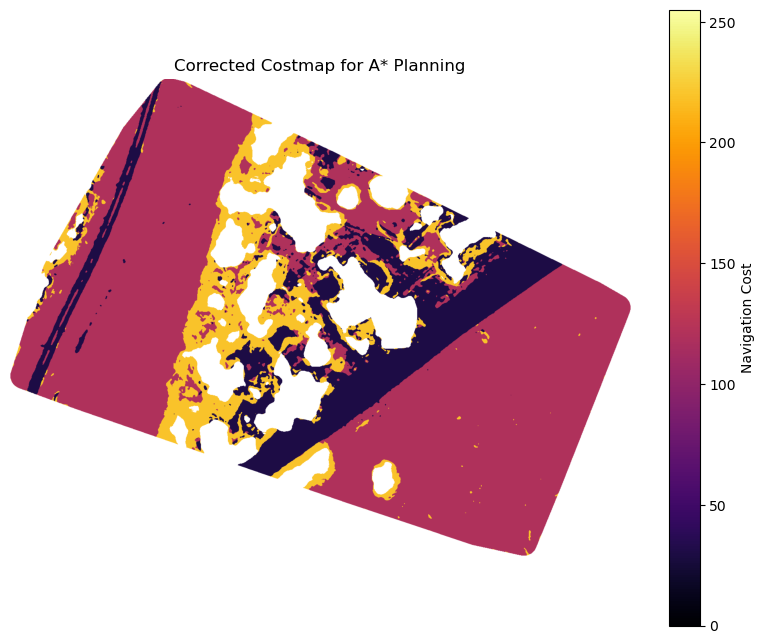

In [75]:
costmap_masked = np.ma.masked_where(costmap == 255, costmap)

cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.figure(figsize=(10, 8))
img = plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)
plt.colorbar(img, label="Navigation Cost")
plt.title("Corrected Costmap for A* Planning")
plt.axis("off")
plt.show()

In [76]:
walkable = costmap < 255

print("Walkable pixels:", walkable.sum())
print("Blocked pixels:", (~walkable).sum())
print("Walkable ratio:", walkable.sum() / walkable.size)

Walkable pixels: 885461
Blocked pixels: 890250
Walkable ratio: 0.4986515260647707


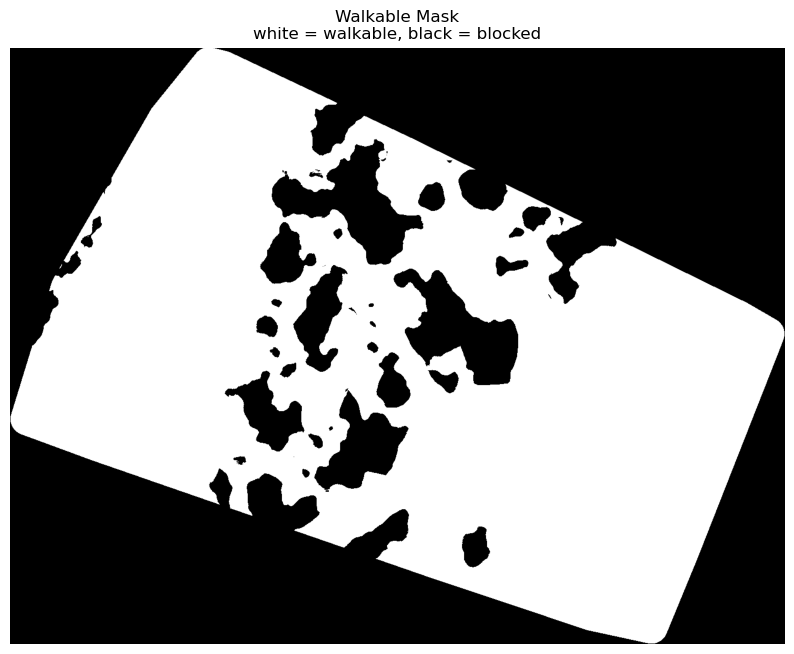

In [77]:
plt.figure(figsize=(10, 8))
plt.imshow(walkable, cmap="gray")
plt.title("Walkable Mask\nwhite = walkable, black = blocked")
plt.axis("off")
plt.show()

In [78]:
easy_pixels = np.argwhere(costmap == 30)

print("Number of easy pixels:", len(easy_pixels))
print("First 10 easy pixels:")
print(easy_pixels[:10])

Number of easy pixels: 165072
First 10 easy pixels:
[[  9 367]
 [  9 368]
 [  9 369]
 [  9 370]
 [ 10 366]
 [ 10 367]
 [ 10 368]
 [ 10 369]
 [ 10 370]
 [ 11 366]]


In [79]:
h, w = costmap.shape

# start: 靠近左上角的 easy 点
dist_to_topleft = easy_pixels[:, 0]**2 + easy_pixels[:, 1]**2
start = tuple(easy_pixels[np.argmin(dist_to_topleft)])

# goal: 靠近右下角的 easy 点
dist_to_bottomright = (easy_pixels[:, 0] - (h - 1))**2 + (easy_pixels[:, 1] - (w - 1))**2
goal = tuple(easy_pixels[np.argmin(dist_to_bottomright)])

print("Start:", start)
print("Goal:", goal)
print("Start cost:", costmap[start])
print("Goal cost:", costmap[goal])

Start: (np.int64(217), np.int64(221))
Goal: (np.int64(775), np.int64(1225))
Start cost: 30
Goal cost: 30


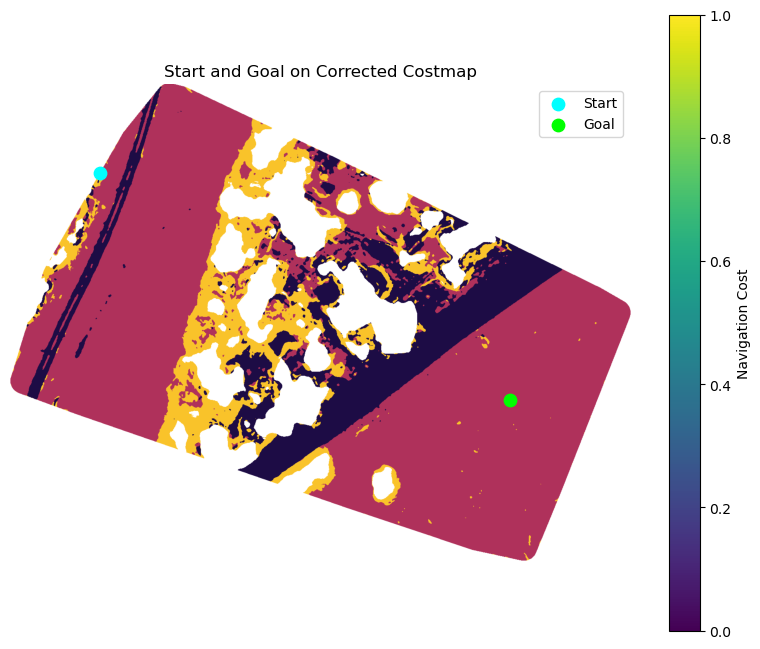

In [80]:
plt.figure(figsize=(10, 8))

costmap_masked = np.ma.masked_where(costmap == 255, costmap)
cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)
plt.scatter(start[1], start[0], c="cyan", s=80, label="Start")
plt.scatter(goal[1], goal[0], c="lime", s=80, label="Goal")

plt.title("Start and Goal on Corrected Costmap")
plt.colorbar(label="Navigation Cost")
plt.legend()
plt.axis("off")
plt.show()

In [81]:
import heapq
import math

In [82]:
def heuristic(a, b):
    """
    Euclidean distance between two pixels.
    a and b are both (row, col).
    """
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

In [83]:
def get_neighbors(node, shape):
    """
    Get 8-neighbor pixels around current node.
    
    node: (row, col)
    shape: costmap shape
    """
    row, col = node
    h, w = shape
    
    directions = [
        (-1,  0),  # up
        ( 1,  0),  # down
        ( 0, -1),  # left
        ( 0,  1),  # right
        (-1, -1),  # up-left
        (-1,  1),  # up-right
        ( 1, -1),  # down-left
        ( 1,  1),  # down-right
    ]
    
    neighbors = []
    
    for dr, dc in directions:
        nr = row + dr
        nc = col + dc
        
        if 0 <= nr < h and 0 <= nc < w:
            neighbors.append((nr, nc))
    
    return neighbors

In [84]:
def move_cost(current, neighbor, costmap, cost_weight=5.0):
    """
    Compute movement cost from current to neighbor.

    current, neighbor: (row, col)
    costmap values:
        30  = easy
        120 = medium
        220 = hard
        255 = blocked
    cost_weight:
        larger value means the path avoids high-cost regions more strongly
    """
    # blocked / invalid area cannot be crossed
    if costmap[neighbor] >= 255:
        return np.inf
    
    # geometric distance: straight = 1, diagonal = sqrt(2)
    dr = abs(current[0] - neighbor[0])
    dc = abs(current[1] - neighbor[1])
    
    if dr == 1 and dc == 1:
        dist = math.sqrt(2)
    else:
        dist = 1.0
    
    # normalize cost to 0–1
    terrain_cost = costmap[neighbor] / 255.0
    
    return dist * (1.0 + cost_weight * terrain_cost)

In [85]:
cost_weight = 5.0

In [86]:
def astar(costmap, start, goal, cost_weight=5.0):
    """
    A* path planning on a costmap.

    costmap: 2D array with values 30, 120, 220, 255
    start: (row, col)
    goal: (row, col)
    cost_weight: how strongly terrain cost affects path planning

    Returns:
        path: list of (row, col), or None if no path found
    """
    if costmap[start] >= 255:
        raise ValueError("Start point is blocked or invalid.")
    
    if costmap[goal] >= 255:
        raise ValueError("Goal point is blocked or invalid.")
    
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0.0}
    
    visited = set()
    
    while open_set:
        current_f, current = heapq.heappop(open_set)
        
        if current in visited:
            continue
        
        visited.add(current)
        
        # goal reached
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path
        
        for neighbor in get_neighbors(current, costmap.shape):
            if neighbor in visited:
                continue
            
            step_cost = move_cost(
                current,
                neighbor,
                costmap,
                cost_weight=cost_weight
            )
            
            if np.isinf(step_cost):
                continue
            
            tentative_g = g_score[current] + step_cost
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
    
    return None

In [87]:
path = astar(costmap, start, goal, cost_weight=5.0)

if path is None:
    print("No path found.")
else:
    print("Path found.")
    print("Path length:", len(path))
    print("First point:", path[0])
    print("Last point:", path[-1])

Path found.
Path length: 1021
First point: (np.int64(217), np.int64(221))
Last point: (np.int64(775), np.int64(1225))


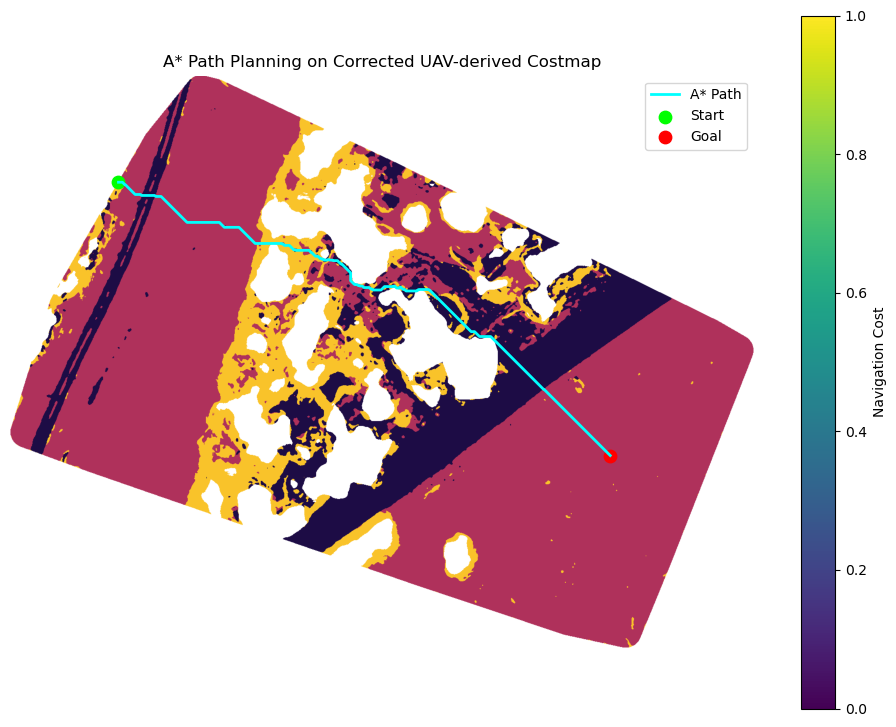

In [88]:
if path is not None:
    path_arr = np.array(path)

    costmap_masked = np.ma.masked_where(costmap == 255, costmap)
    cmap_cost = plt.cm.inferno.copy()
    cmap_cost.set_bad(color="white")

    plt.figure(figsize=(12, 9))
    plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)

    plt.plot(
        path_arr[:, 1],
        path_arr[:, 0],
        color="cyan",
        linewidth=2,
        label="A* Path"
    )

    plt.scatter(start[1], start[0], c="lime", s=80, label="Start")
    plt.scatter(goal[1], goal[0], c="red", s=80, label="Goal")

    plt.title("A* Path Planning on Corrected UAV-derived Costmap")
    plt.colorbar(label="Navigation Cost")
    plt.legend()
    plt.axis("off")
    plt.show()

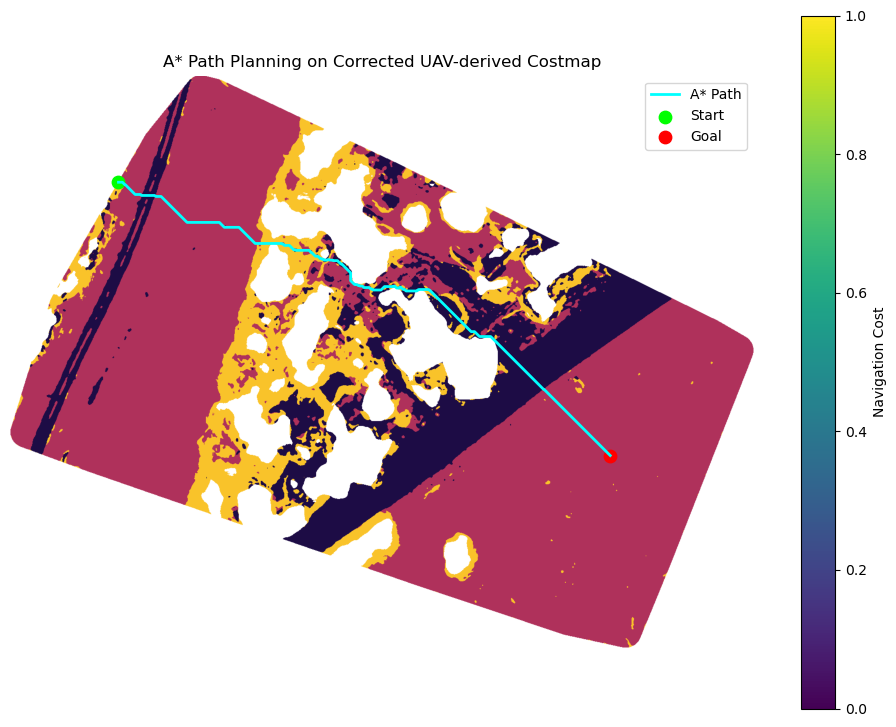

Saved: ../outputs/figures/astar_path_on_corrected_costmap.png


In [89]:
if path is not None:
    os.makedirs("../outputs/figures", exist_ok=True)

    path_arr = np.array(path)

    costmap_masked = np.ma.masked_where(costmap == 255, costmap)
    cmap_cost = plt.cm.inferno.copy()
    cmap_cost.set_bad(color="white")

    plt.figure(figsize=(12, 9))
    plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)

    plt.plot(
        path_arr[:, 1],
        path_arr[:, 0],
        color="cyan",
        linewidth=2,
        label="A* Path"
    )

    plt.scatter(start[1], start[0], c="lime", s=80, label="Start")
    plt.scatter(goal[1], goal[0], c="red", s=80, label="Goal")

    plt.title("A* Path Planning on Corrected UAV-derived Costmap")
    plt.colorbar(label="Navigation Cost")
    plt.legend()
    plt.axis("off")

    plt.savefig("../outputs/figures/astar_path_on_corrected_costmap.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved: ../outputs/figures/astar_path_on_corrected_costmap.png")

In [90]:
if path is not None:
    os.makedirs("../outputs/paths", exist_ok=True)

    path_arr = np.array(path)

    np.savetxt(
        "../outputs/paths/astar_path_pixels.csv",
        path_arr,
        delimiter=",",
        header="row,col",
        comments="",
        fmt="%d"
    )

    print("Saved: ../outputs/paths/astar_path_pixels.csv")

Saved: ../outputs/paths/astar_path_pixels.csv


In [91]:
print("Path length:", len(path))
print("Costmap shape:", costmap.shape)
print("Path first:", path[0])
print("Path last:", path[-1])

Path length: 1021
Costmap shape: (1169, 1519)
Path first: (np.int64(217), np.int64(221))
Path last: (np.int64(775), np.int64(1225))


In [92]:
path_arr = np.array(path)

rows = path_arr[:, 0]
cols = path_arr[:, 1]

print("path_arr shape:", path_arr.shape)

path_arr shape: (1021, 2)


In [93]:
step = max(1, len(path_arr) // 300)

path_downsampled = path_arr[::step]

# 保证最后一个点一定是 goal
if not np.array_equal(path_downsampled[-1], path_arr[-1]):
    path_downsampled = np.vstack([path_downsampled, path_arr[-1]])

print("Original path length:", len(path_arr))
print("Downsampled path length:", len(path_downsampled))

Original path length: 1021
Downsampled path length: 341


In [94]:
def moving_average_path(path_array, window_size=9):
    """
    Smooth path using moving average.
    path_array: Nx2 array with row,col
    """
    if window_size % 2 == 0:
        window_size += 1

    half = window_size // 2
    smoothed = path_array.astype(float).copy()

    for i in range(half, len(path_array) - half):
        smoothed[i, 0] = np.mean(path_array[i-half:i+half+1, 0])
        smoothed[i, 1] = np.mean(path_array[i-half:i+half+1, 1])

    # keep exact start and goal
    smoothed[0] = path_array[0]
    smoothed[-1] = path_array[-1]

    return smoothed

In [95]:
path_smooth = moving_average_path(path_downsampled, window_size=9)

print("Smoothed path shape:", path_smooth.shape)

Smoothed path shape: (341, 2)


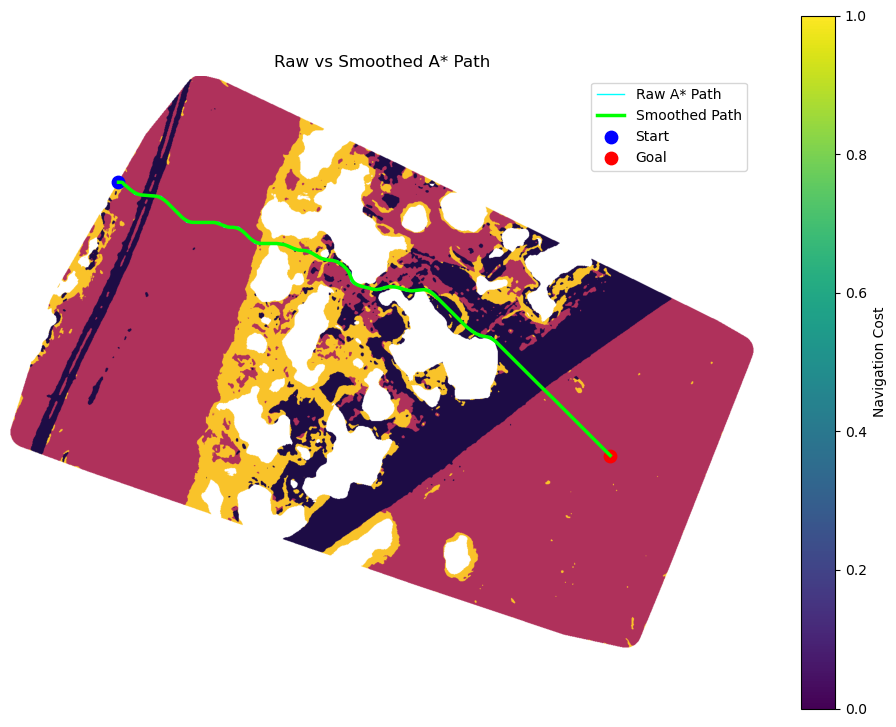

In [96]:
plt.figure(figsize=(12, 9))

costmap_masked = np.ma.masked_where(costmap == 255, costmap)
cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)

plt.plot(path_arr[:, 1], path_arr[:, 0], color="cyan", linewidth=1, label="Raw A* Path")
plt.plot(path_smooth[:, 1], path_smooth[:, 0], color="lime", linewidth=2.5, label="Smoothed Path")

plt.scatter(start[1], start[0], c="blue", s=80, label="Start")
plt.scatter(goal[1], goal[0], c="red", s=80, label="Goal")

plt.title("Raw vs Smoothed A* Path")
plt.colorbar(label="Navigation Cost")
plt.legend()
plt.axis("off")
plt.show()

In [97]:
def check_path_collision(path_float, costmap):
    """
    Check whether rounded smoothed path crosses blocked cells.
    """
    collisions = 0
    h, w = costmap.shape

    for r, c in path_float:
        rr = int(round(r))
        cc = int(round(c))

        if rr < 0 or rr >= h or cc < 0 or cc >= w:
            collisions += 1
        elif costmap[rr, cc] >= 255:
            collisions += 1

    return collisions

collisions = check_path_collision(path_smooth, costmap)

print("Smoothed path collisions:", collisions)

Smoothed path collisions: 10


In [98]:
path_smooth = moving_average_path(path_downsampled, window_size=5)
collisions = check_path_collision(path_smooth, costmap)
print("Smoothed path collisions:", collisions)

Smoothed path collisions: 5


In [103]:
# Try different smoothing levels
candidates = {}

path_smooth_9 = moving_average_path(path_downsampled, window_size=9)
candidates["smooth_9"] = (path_smooth_9, check_path_collision(path_smooth_9, costmap))

path_smooth_5 = moving_average_path(path_downsampled, window_size=5)
candidates["smooth_5"] = (path_smooth_5, check_path_collision(path_smooth_5, costmap))

path_smooth_3 = moving_average_path(path_downsampled, window_size=3)
candidates["smooth_3"] = (path_smooth_3, check_path_collision(path_smooth_3, costmap))

candidates["downsampled"] = (path_downsampled.astype(float), check_path_collision(path_downsampled, costmap))

for name, (_, collisions) in candidates.items():
    print(name, "collisions:", collisions)

# Choose the first collision-free option
final_path = None
final_name = None

for name in ["smooth_9", "smooth_5", "smooth_3", "downsampled"]:
    candidate_path, collisions = candidates[name]
    if collisions == 0:
        final_path = candidate_path
        final_name = name
        break

if final_path is None:
    # If all have collisions, use raw A* path as safest fallback
    final_path = path_arr.astype(float)
    final_name = "raw_astar"

print("Selected final path:", final_name)
print("Final path length:", len(final_path))
print("Final collisions:", check_path_collision(final_path, costmap))

smooth_9 collisions: 10
smooth_5 collisions: 5
smooth_3 collisions: 2
downsampled collisions: 0
Selected final path: downsampled
Final path length: 341
Final collisions: 0


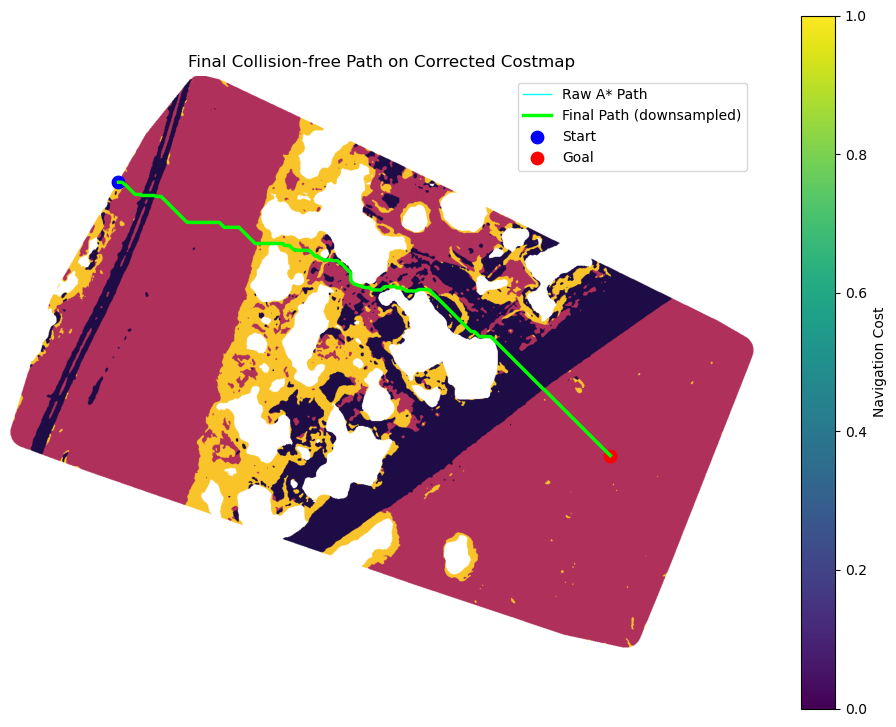

In [104]:
plt.figure(figsize=(12, 9))

costmap_masked = np.ma.masked_where(costmap == 255, costmap)
cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)

plt.plot(path_arr[:, 1], path_arr[:, 0], color="cyan", linewidth=1, label="Raw A* Path")
plt.plot(final_path[:, 1], final_path[:, 0], color="lime", linewidth=2.5, label=f"Final Path ({final_name})")

plt.scatter(start[1], start[0], c="blue", s=80, label="Start")
plt.scatter(goal[1], goal[0], c="red", s=80, label="Goal")

plt.title("Final Collision-free Path on Corrected Costmap")
plt.colorbar(label="Navigation Cost")
plt.legend()
plt.axis("off")
plt.show()

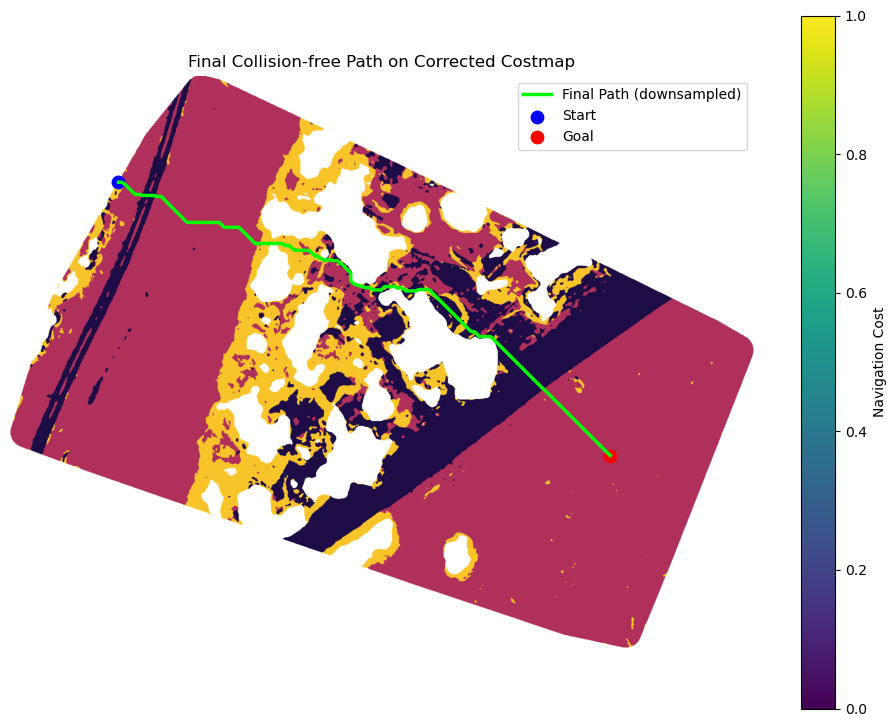

Saved final path.


In [105]:
os.makedirs("../outputs/paths", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

np.savetxt(
    "../outputs/paths/final_path_pixels.csv",
    final_path,
    delimiter=",",
    header="row,col",
    comments="",
    fmt="%.3f"
)

plt.figure(figsize=(12, 9))

costmap_masked = np.ma.masked_where(costmap == 255, costmap)
cmap_cost = plt.cm.inferno.copy()
cmap_cost.set_bad(color="white")

plt.imshow(costmap_masked, cmap=cmap_cost, vmin=0, vmax=255)
plt.plot(final_path[:, 1], final_path[:, 0], color="lime", linewidth=2.5, label=f"Final Path ({final_name})")
plt.scatter(start[1], start[0], c="blue", s=80, label="Start")
plt.scatter(goal[1], goal[0], c="red", s=80, label="Goal")

plt.title("Final Collision-free Path on Corrected Costmap")
plt.colorbar(label="Navigation Cost")
plt.legend()
plt.axis("off")

plt.savefig("../outputs/figures/final_path_on_corrected_costmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved final path.")

In [106]:
print("Final path name:", final_name)
print("Final path shape:", final_path.shape)
print("Final collisions:", check_path_collision(final_path, costmap))
print("First point:", final_path[0])
print("Last point:", final_path[-1])

Final path name: downsampled
Final path shape: (341, 2)
Final collisions: 0
First point: [217. 221.]
Last point: [ 775. 1225.]


In [107]:
import rasterio
import numpy as np

def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, profile

dtm, dtm_profile = read_raster("../data_aligned/dtm_aligned.tif")

print("DTM shape:", dtm.shape)
print("DTM min:", np.nanmin(dtm))
print("DTM max:", np.nanmax(dtm))
print("DTM mean:", np.nanmean(dtm))

DTM shape: (1169, 1519)
DTM min: 8.18
DTM max: 31.6
DTM mean: 20.163446


In [108]:
from rasterio.transform import xy

xyz_path = []

for r, c in final_path:
    rr = int(round(r))
    cc = int(round(c))

    x, y = xy(dtm_profile["transform"], rr, cc)
    z = dtm[rr, cc]

    xyz_path.append((x, y, z))

xyz_path = np.array(xyz_path)

print("XYZ path shape:", xyz_path.shape)
print("First XYZ:", xyz_path[0])
print("Last XYZ:", xyz_path[-1])

XYZ path shape: (341, 3)
First XYZ: [3.24503026e+05 6.00681601e+06 2.51200008e+01]
Last XYZ: [3.24594501e+05 6.00676517e+06 1.62535954e+01]


In [109]:
print("NaN in xyz_path:", np.isnan(xyz_path).sum())
print("Z min:", np.nanmin(xyz_path[:, 2]))
print("Z max:", np.nanmax(xyz_path[:, 2]))

NaN in xyz_path: 0
Z min: 16.25359535217285
Z max: 27.579999923706055


In [110]:
import os

os.makedirs("../outputs/paths", exist_ok=True)

np.savetxt(
    "../outputs/paths/final_path_xyz.csv",
    xyz_path,
    delimiter=",",
    header="x,y,z",
    comments="",
    fmt="%.6f"
)

print("Saved: ../outputs/paths/final_path_xyz.csv")

Saved: ../outputs/paths/final_path_xyz.csv


In [111]:
np.savetxt(
    "../outputs/paths/final_path_pixels.csv",
    final_path,
    delimiter=",",
    header="row,col",
    comments="",
    fmt="%.3f"
)

print("Saved: ../outputs/paths/final_path_pixels.csv")

Saved: ../outputs/paths/final_path_pixels.csv


In [112]:
skip = 10

dtm_plot = dtm[::skip, ::skip]

rows_grid, cols_grid = np.indices(dtm.shape)
rows_plot = rows_grid[::skip, ::skip]
cols_plot = cols_grid[::skip, ::skip]

X_plot = cols_plot
Y_plot = rows_plot
Z_plot = dtm_plot

print("DTM plot shape:", Z_plot.shape)

DTM plot shape: (117, 152)


In [113]:
path_z = []

for r, c in final_path:
    rr = int(round(r))
    cc = int(round(c))
    path_z.append(dtm[rr, cc] + 0.5)

path_z = np.array(path_z)

print("Path Z min:", np.nanmin(path_z))
print("Path Z max:", np.nanmax(path_z))

Path Z min: 16.753595
Path Z max: 28.08


In [118]:
ax.view_init(elev=-45, azim=60)
plt.show()

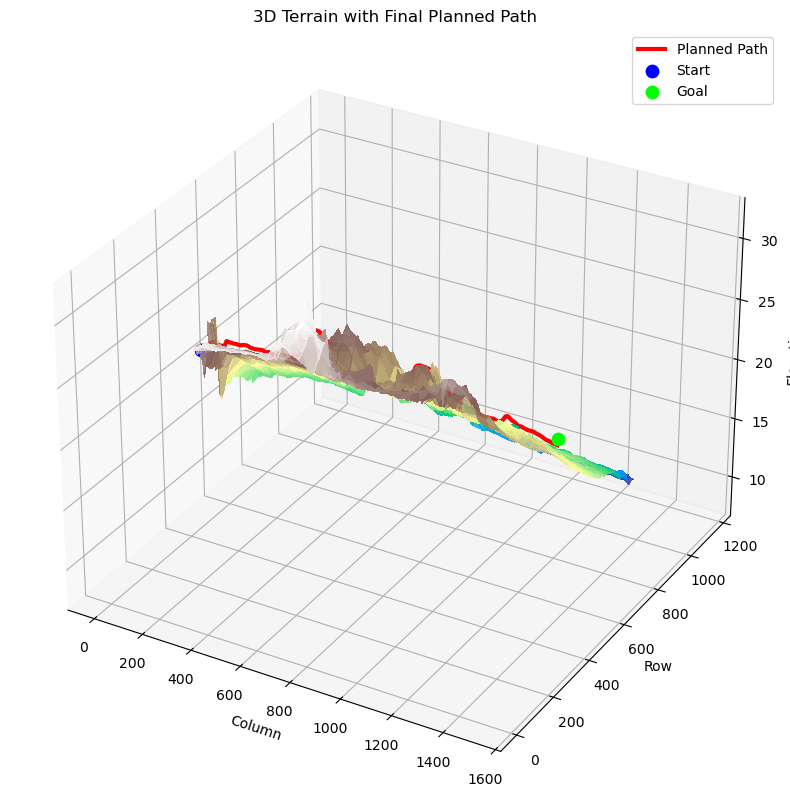

In [119]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# 地形表面
ax.plot_surface(
    X_plot,
    Y_plot,
    Z_plot,
    cmap="terrain",
    linewidth=0,
    antialiased=False,
    alpha=0.8
)

# 路径
ax.plot(
    final_path[:, 1],
    final_path[:, 0],
    path_z,
    color="red",
    linewidth=3,
    label="Planned Path"
)

# 起点终点
start_r, start_c = int(round(final_path[0, 0])), int(round(final_path[0, 1]))
goal_r, goal_c = int(round(final_path[-1, 0])), int(round(final_path[-1, 1]))

ax.scatter(
    start_c,
    start_r,
    dtm[start_r, start_c] + 1.0,
    color="blue",
    s=80,
    label="Start"
)

ax.scatter(
    goal_c,
    goal_r,
    dtm[goal_r, goal_c] + 1.0,
    color="lime",
    s=80,
    label="Goal"
)

ax.set_title("3D Terrain with Final Planned Path")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_zlabel("Elevation")
ax.legend()

plt.show()

In [120]:
dtm_for_plot = dtm.copy()
dtm_for_plot = np.where(np.isfinite(dtm_for_plot), dtm_for_plot, np.nan)

In [121]:
path_z = []

for r, c in final_path:
    rr = int(round(r))
    cc = int(round(c))
    path_z.append(dtm[rr, cc] + 1.5)

path_z = np.array(path_z)

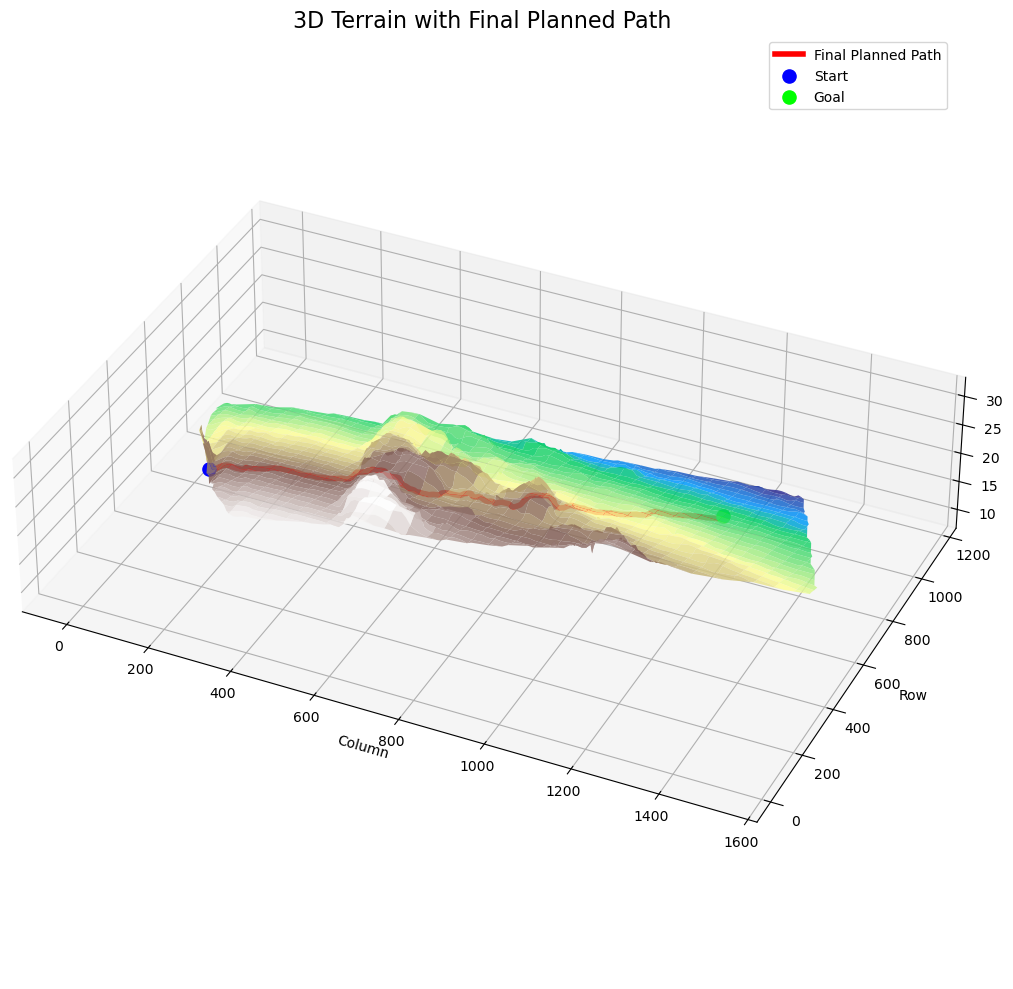

In [122]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import os

skip = 10

dtm_plot = dtm_for_plot[::skip, ::skip]

rows_grid, cols_grid = np.indices(dtm.shape)
rows_plot = rows_grid[::skip, ::skip]
cols_plot = cols_grid[::skip, ::skip]

X_plot = cols_plot
Y_plot = rows_plot
Z_plot = dtm_plot

# Path height
path_z = []
for r, c in final_path:
    rr = int(round(r))
    cc = int(round(c))
    path_z.append(dtm[rr, cc] + 1.5)

path_z = np.array(path_z)

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection="3d")

# Terrain
ax.plot_surface(
    X_plot,
    Y_plot,
    Z_plot,
    cmap="terrain",
    linewidth=0,
    antialiased=True,
    alpha=0.85
)

# Final path
ax.plot(
    final_path[:, 1],
    final_path[:, 0],
    path_z,
    color="red",
    linewidth=4,
    label="Final Planned Path"
)

# Start and goal
start_r, start_c = int(round(final_path[0, 0])), int(round(final_path[0, 1]))
goal_r, goal_c = int(round(final_path[-1, 0])), int(round(final_path[-1, 1]))

ax.scatter(
    start_c,
    start_r,
    dtm[start_r, start_c] + 2.0,
    color="blue",
    s=90,
    label="Start"
)

ax.scatter(
    goal_c,
    goal_r,
    dtm[goal_r, goal_c] + 2.0,
    color="lime",
    s=90,
    label="Goal"
)

ax.set_title("3D Terrain with Final Planned Path", fontsize=16)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_zlabel("Elevation")

# Better view angle
ax.view_init(elev=35, azim=-65)

# Improve visual proportion
ax.set_box_aspect((3, 2, 0.7))

ax.legend()
plt.tight_layout()
plt.show()

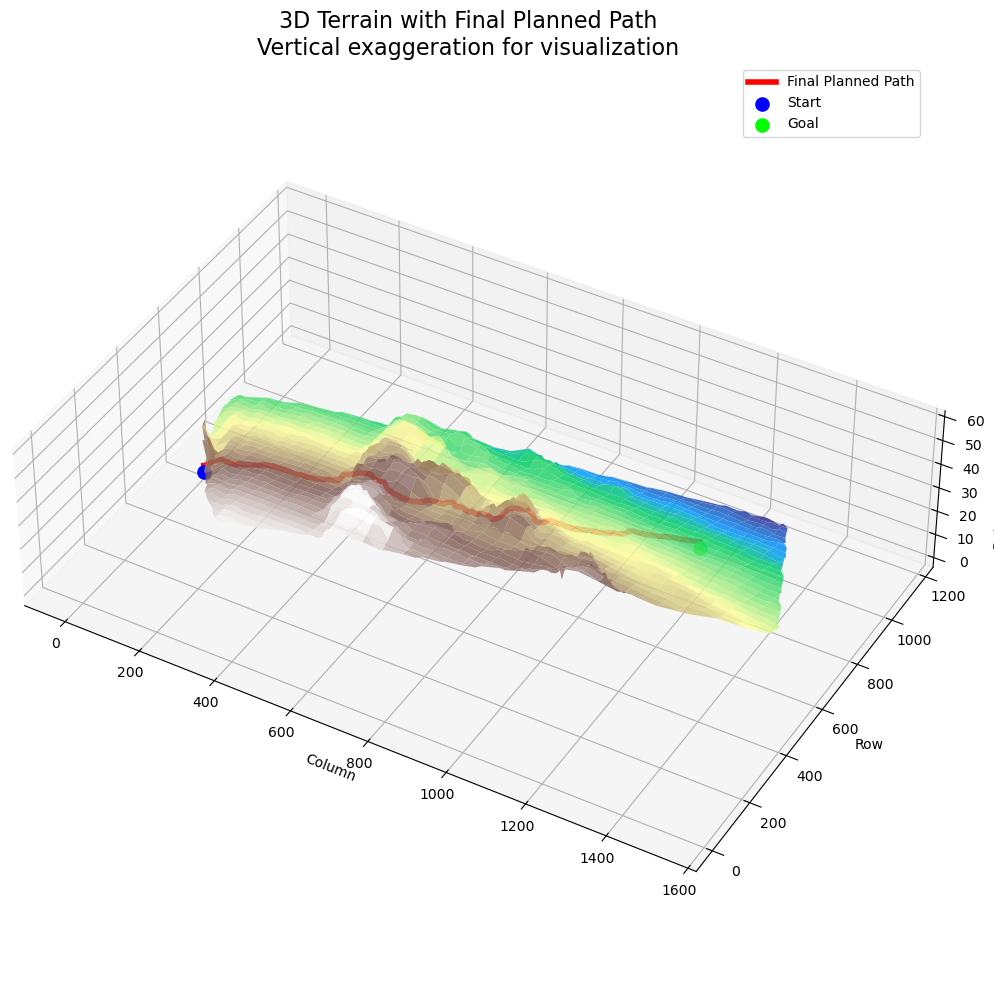

In [123]:
z_exaggeration = 2.5

Z_plot_exag = (Z_plot - np.nanmin(Z_plot)) * z_exaggeration
path_z_exag = (path_z - np.nanmin(dtm)) * z_exaggeration

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X_plot,
    Y_plot,
    Z_plot_exag,
    cmap="terrain",
    linewidth=0,
    antialiased=True,
    alpha=0.85
)

ax.plot(
    final_path[:, 1],
    final_path[:, 0],
    path_z_exag + 2.0,
    color="red",
    linewidth=4,
    label="Final Planned Path"
)

ax.scatter(
    start_c,
    start_r,
    (dtm[start_r, start_c] - np.nanmin(dtm)) * z_exaggeration + 3.0,
    color="blue",
    s=90,
    label="Start"
)

ax.scatter(
    goal_c,
    goal_r,
    (dtm[goal_r, goal_c] - np.nanmin(dtm)) * z_exaggeration + 3.0,
    color="lime",
    s=90,
    label="Goal"
)

ax.set_title("3D Terrain with Final Planned Path\nVertical exaggeration for visualization", fontsize=16)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_zlabel("Relative Elevation")

ax.view_init(elev=40, azim=-60)
ax.set_box_aspect((3, 2, 0.8))

ax.legend()
plt.tight_layout()
plt.show()

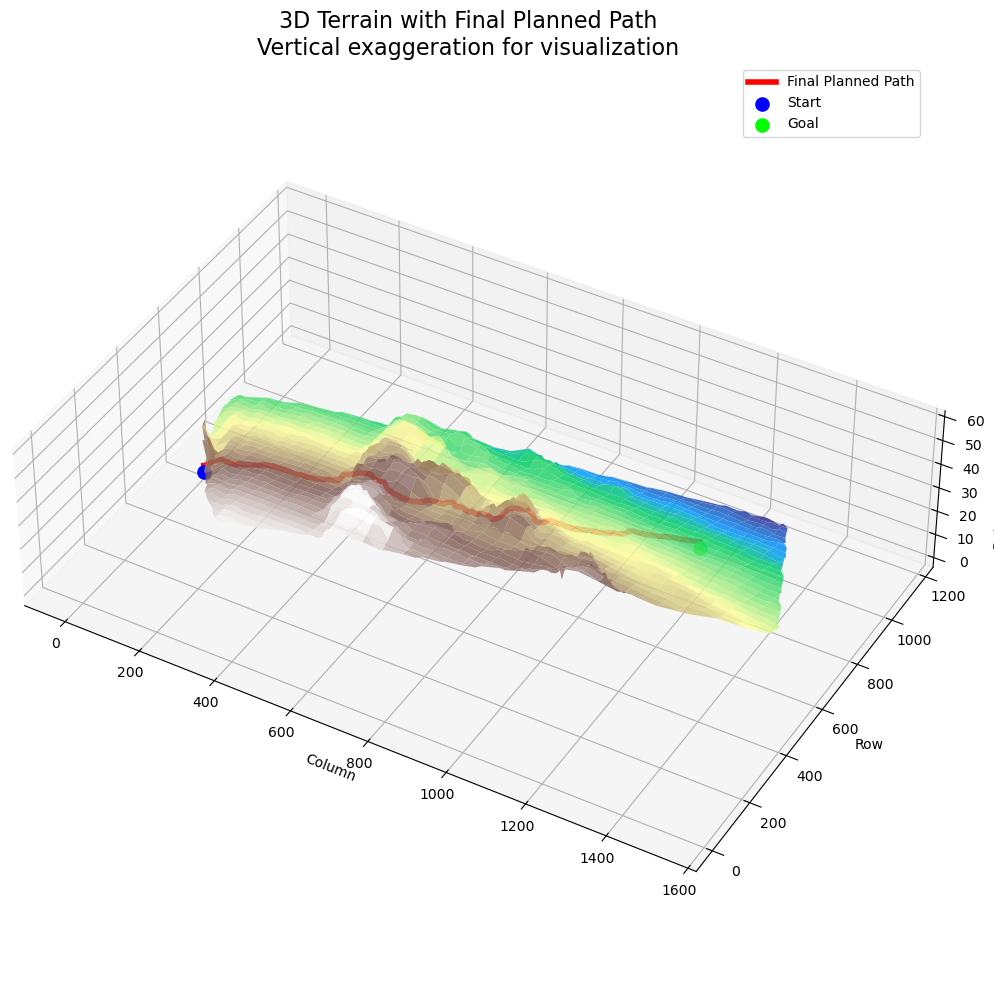

Saved: ../outputs/figures/3d_terrain_with_final_path_clear.png


In [124]:
os.makedirs("../outputs/figures", exist_ok=True)

z_exaggeration = 2.5
Z_plot_exag = (Z_plot - np.nanmin(Z_plot)) * z_exaggeration
path_z_exag = (path_z - np.nanmin(dtm)) * z_exaggeration

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X_plot,
    Y_plot,
    Z_plot_exag,
    cmap="terrain",
    linewidth=0,
    antialiased=True,
    alpha=0.85
)

ax.plot(
    final_path[:, 1],
    final_path[:, 0],
    path_z_exag + 2.0,
    color="red",
    linewidth=4,
    label="Final Planned Path"
)

ax.scatter(
    start_c,
    start_r,
    (dtm[start_r, start_c] - np.nanmin(dtm)) * z_exaggeration + 3.0,
    color="blue",
    s=90,
    label="Start"
)

ax.scatter(
    goal_c,
    goal_r,
    (dtm[goal_r, goal_c] - np.nanmin(dtm)) * z_exaggeration + 3.0,
    color="lime",
    s=90,
    label="Goal"
)

ax.set_title("3D Terrain with Final Planned Path\nVertical exaggeration for visualization", fontsize=16)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_zlabel("Relative Elevation")

ax.view_init(elev=40, azim=-60)
ax.set_box_aspect((3, 2, 0.8))

ax.legend()
plt.tight_layout()

plt.savefig("../outputs/figures/3d_terrain_with_final_path_clear.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ../outputs/figures/3d_terrain_with_final_path_clear.png")